## Advanced Research Topics Assignment 1:  Time series case study:
# Forecasting weekly German electricity demand

#Part 1:

Retrieve the data:
We will be using the publicly available data from here: https://data.open-power-system-data.org/time_series/. This contains data from many countries up to October 2020. We are interested in the German data, which is known by it's country identifier 'DE'.

Download the 60 minute data file: https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv

You will need to bin the data up using e.g. Pandas, to weekly and daily values.
Keep only values from January 1st 2015 until the end of the file, October 2020.
Make initial plots of the data and perform any EDA
Identify what components there are in the time series. Is there and seasonal component?
Perform all the time series analysis tasks to test for non-stationarity

In [ ]:
!pip install pandas matplotlib seaborn statsmodels

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style("whitegrid")

Start date: 2015-01-01 00:00:00+00:00
End date: 2020-09-30 23:00:00+00:00
Number of observations: 50400
Missing values: 0

Daily observations: 2100
Weekly observations: 301

Daily summary statistics:
count     2100.000000
mean     55492.468552
std       6601.474342
min      38952.666667
25%      50413.447917
50%      56776.916667
75%      60430.093750
max      68183.583333
Name: load_mw, dtype: float64

Weekly summary statistics:
count      301.000000
mean     55484.350477
std       3762.742475
min      46505.309524
25%      52845.267857
50%      54858.434524
75%      58688.470238
max      63587.011905
Name: load_mw, dtype: float64


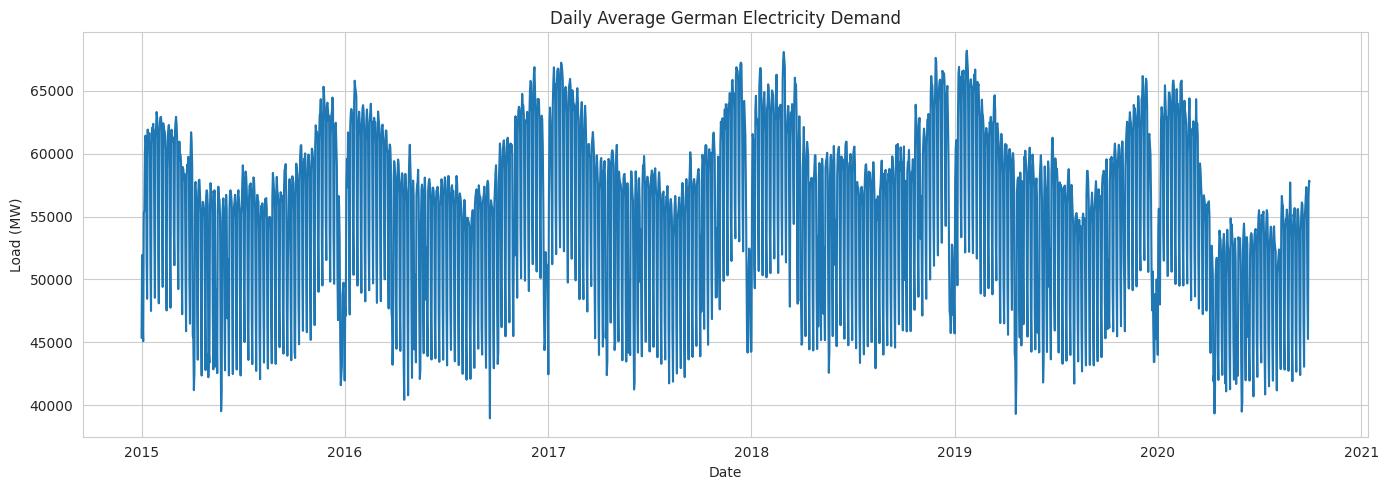

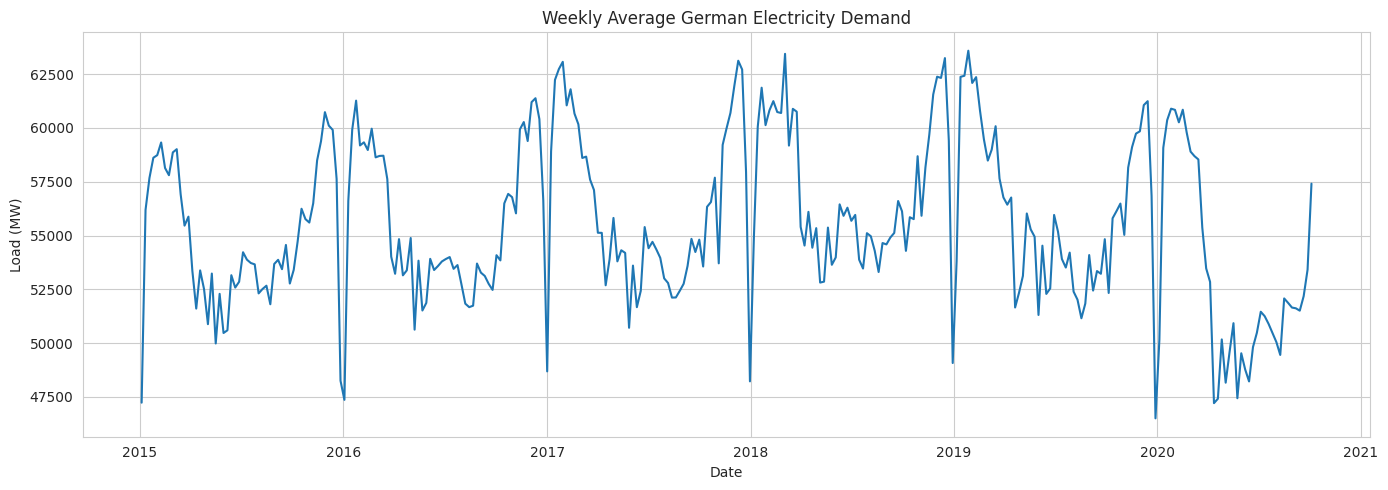

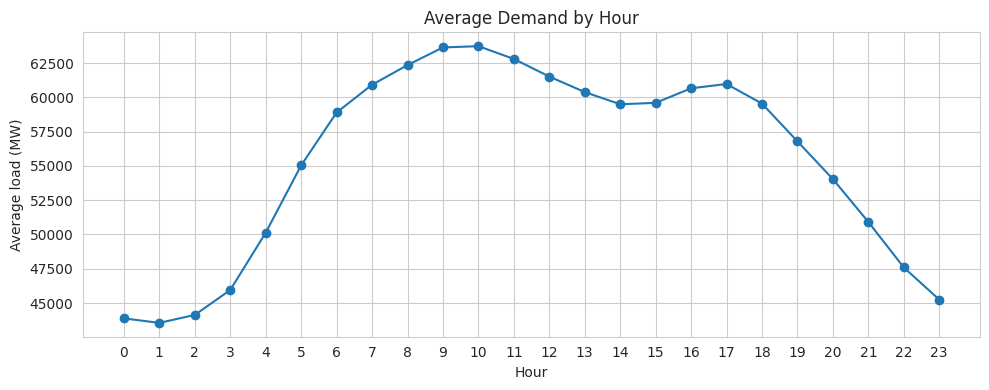

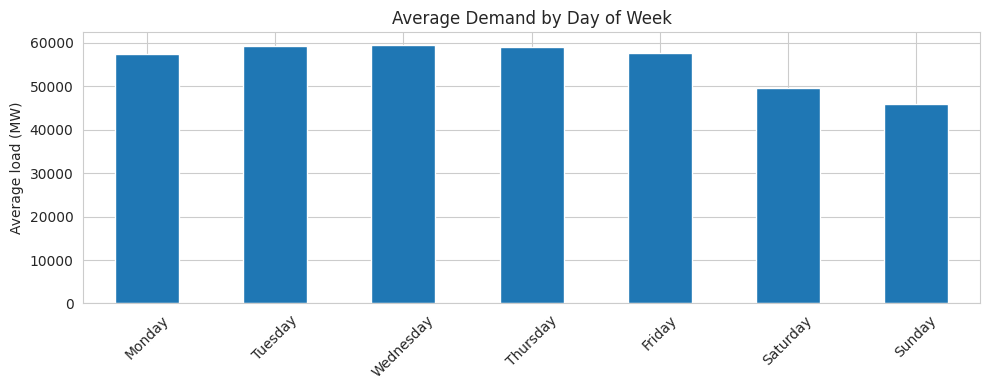

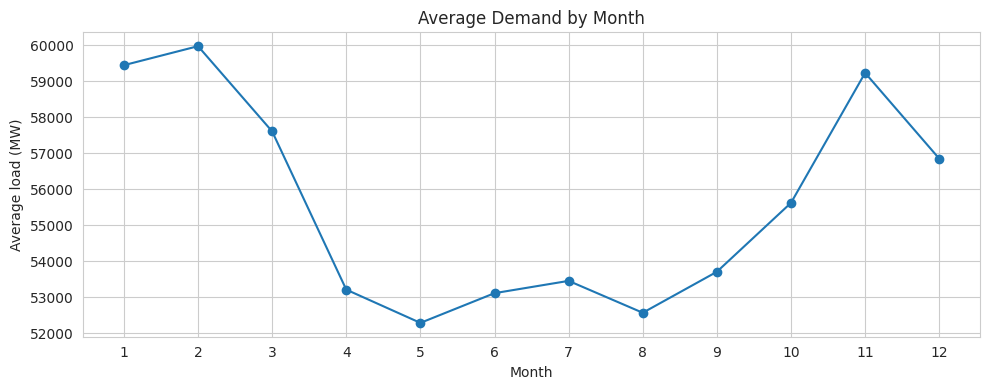

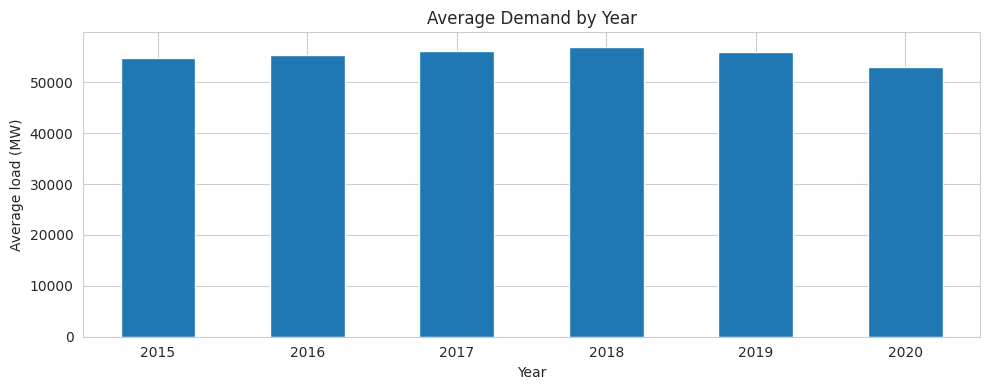

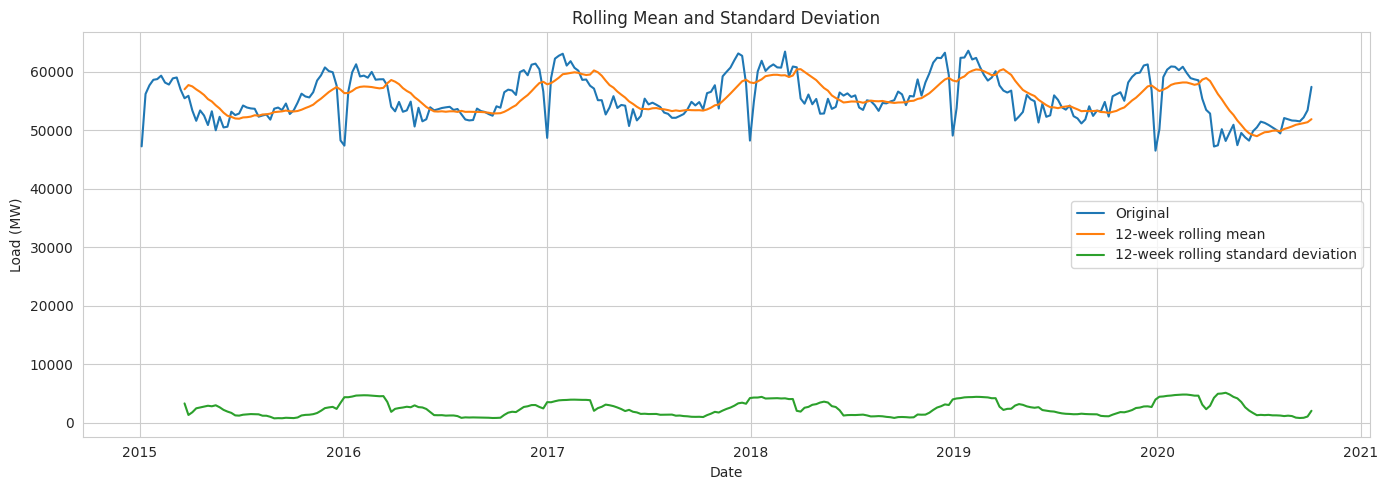

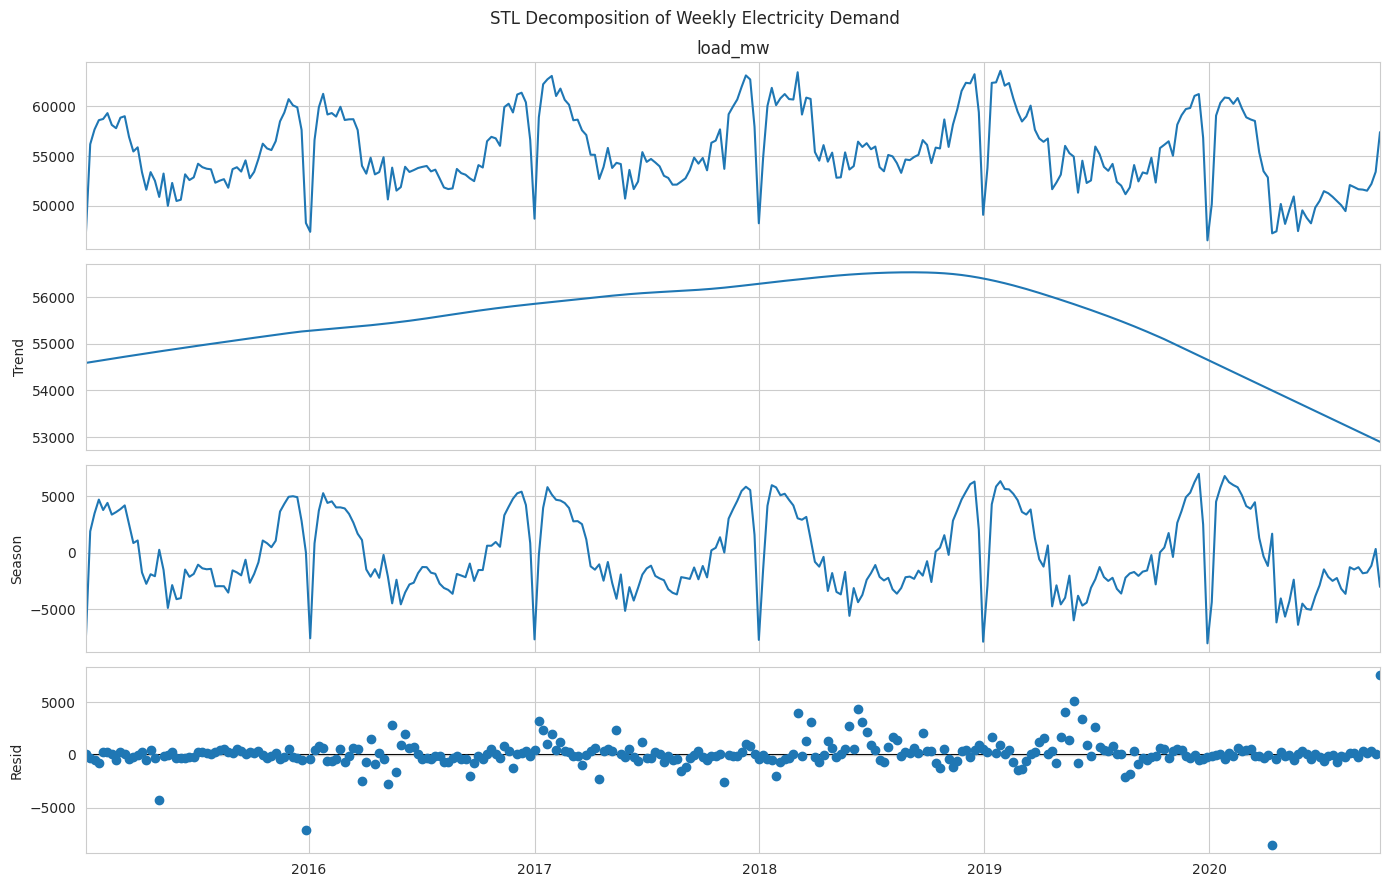


Seasonal strength: 0.871

Time-series components:

1. Trend:
   Long-term movement in electricity demand.

2. Seasonal component:
   Repeating hourly, weekly and annual patterns.

3. Irregular component:
   Random changes caused by weather, holidays and unusual events.

Yes, the electricity-demand series contains a seasonal component.



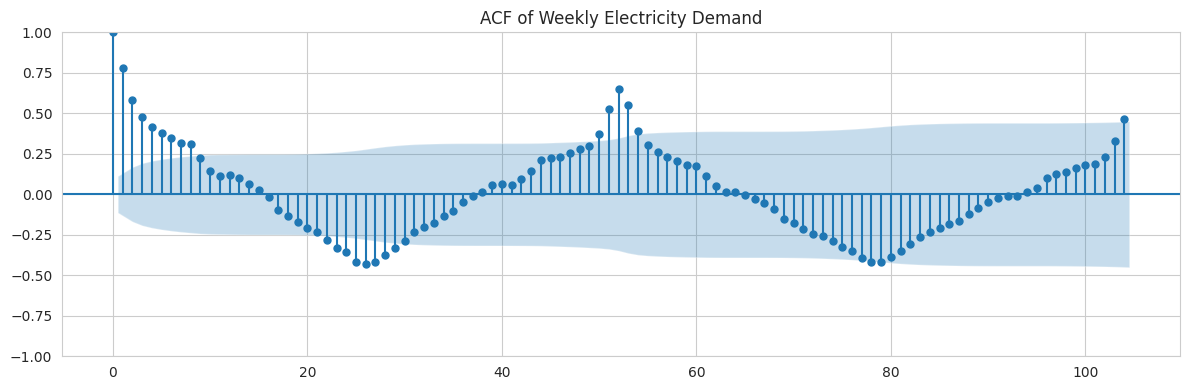

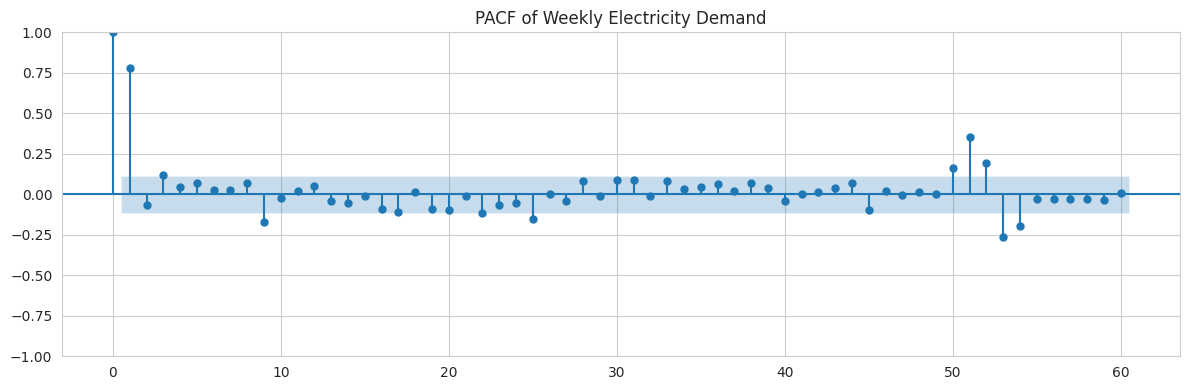


Stationarity test results:
                                 Series  ADF statistic  ADF p-value  \
0                        Daily original        -4.5935       0.0001   
1                Daily first difference       -14.2229       0.0000   
2             Daily seasonal difference       -11.0540       0.0000   
3   Daily first and seasonal difference       -17.7538       0.0000   
4                       Weekly original        -4.0475       0.0012   
5               Weekly first difference        -7.0693       0.0000   
6            Weekly seasonal difference        -4.2951       0.0005   
7  Weekly first and seasonal difference        -7.2776       0.0000   

   KPSS statistic  KPSS p-value  
0          0.5395        0.0328  
1          0.0304        0.1000  
2          0.0151        0.1000  
3          0.0452        0.1000  
4          0.1604        0.1000  
5          0.0558        0.1000  
6          1.3419        0.0100  
7          0.1052        0.1000  

Daily original
ADF result

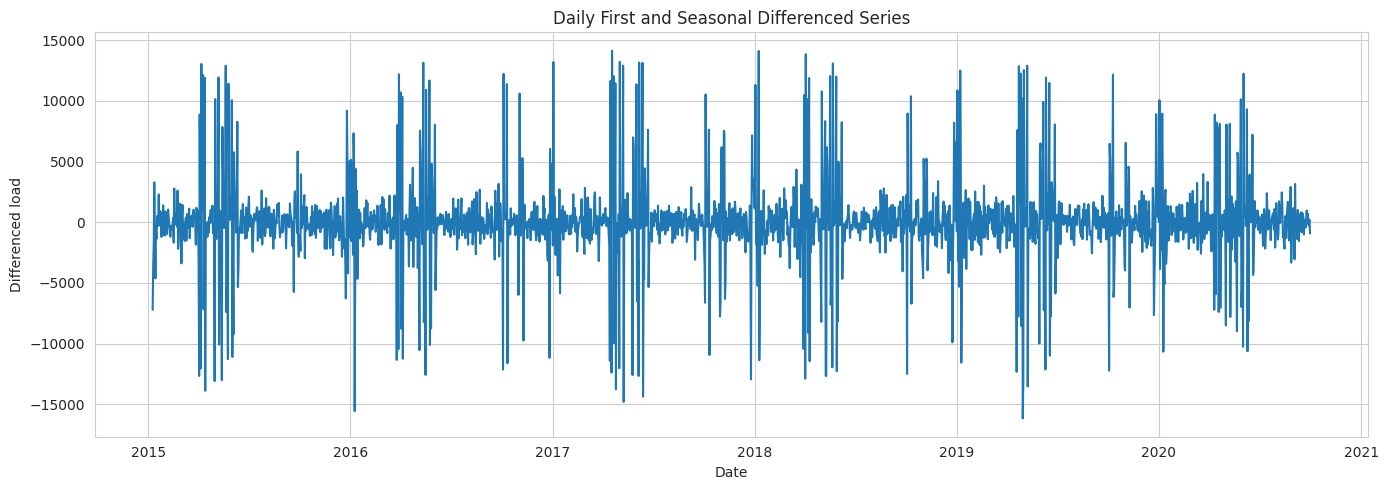

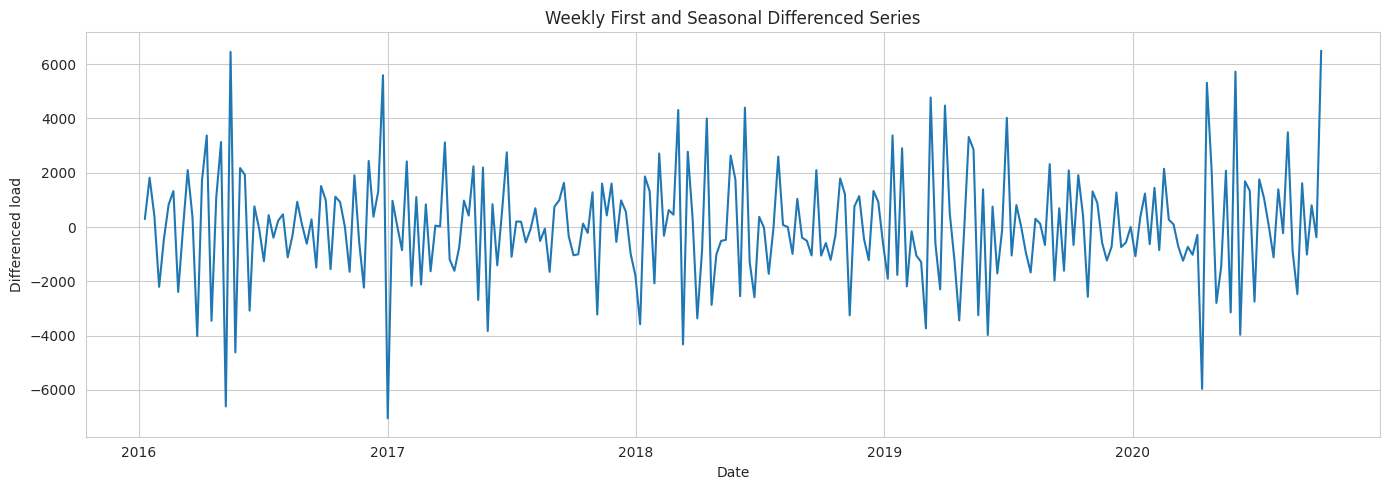

In [ ]:
# German electricity-demand time-series analysis

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Load German electricity-demand data


df = pd.read_csv(
    "time_series_60min_singleindex.csv",
    usecols=[
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency"
    ],
    parse_dates=["utc_timestamp"]
)

df = df.rename(
    columns={
        "utc_timestamp": "timestamp",
        "DE_load_actual_entsoe_transparency": "load_mw"
    }
)

df = df.set_index("timestamp").sort_index()

# 2. Keep data from 1 January 2015 to the end of the file

df = df.loc["2015-01-01":].copy()

print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Number of observations:", len(df))
print("Missing values:", df["load_mw"].isna().sum())

df = df.dropna(subset=["load_mw"])


# 3. Bin the hourly data into daily and weekly values

daily = df["load_mw"].resample("D").mean()
weekly = df["load_mw"].resample("W-SUN").mean()

print("\nDaily observations:", len(daily))
print("Weekly observations:", len(weekly))

print("\nDaily summary statistics:")
print(daily.describe())

print("\nWeekly summary statistics:")
print(weekly.describe())


# 4. Initial plots


plt.figure(figsize=(14, 5))
plt.plot(daily.index, daily)
plt.title("Daily Average German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly)
plt.title("Weekly Average German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()


# 5. Exploratory Data Analysis

eda = df.copy()

eda["hour"] = eda.index.hour
eda["weekday"] = eda.index.day_name()
eda["month"] = eda.index.month
eda["year"] = eda.index.year


# Hourly pattern

hourly_pattern = eda.groupby("hour")["load_mw"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_pattern.index, hourly_pattern, marker="o")
plt.title("Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average load (MW)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()


# Weekly pattern

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_pattern = (
    eda.groupby("weekday")["load_mw"]
    .mean()
    .reindex(weekday_order)
)

plt.figure(figsize=(10, 4))
weekday_pattern.plot(kind="bar")
plt.title("Average Demand by Day of Week")
plt.xlabel("")
plt.ylabel("Average load (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Monthly pattern

monthly_pattern = eda.groupby("month")["load_mw"].mean()

plt.figure(figsize=(10, 4))
plt.plot(monthly_pattern.index, monthly_pattern, marker="o")
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average load (MW)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


# Yearly pattern

yearly_pattern = eda.groupby("year")["load_mw"].mean()

plt.figure(figsize=(10, 4))
yearly_pattern.plot(kind="bar")
plt.title("Average Demand by Year")
plt.xlabel("Year")
plt.ylabel("Average load (MW)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 6. Rolling statistics

rolling_mean = weekly.rolling(12).mean()
rolling_std = weekly.rolling(12).std()

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly, label="Original")
plt.plot(rolling_mean.index, rolling_mean, label="12-week rolling mean")
plt.plot(rolling_std.index, rolling_std, label="12-week rolling standard deviation")
plt.title("Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


# 7. Identify time-series components

# Weekly data have approximately 52 observations per year.

stl = STL(
    weekly.dropna(),
    period=52,
    robust=True
)

decomposition = stl.fit()

figure = decomposition.plot()
figure.set_size_inches(14, 9)
plt.suptitle("STL Decomposition of Weekly Electricity Demand")
plt.tight_layout()
plt.show()


seasonal_strength = max(
    0,
    1 - (
        decomposition.resid.var()
        / (decomposition.seasonal + decomposition.resid).var()
    )
)

print("\nSeasonal strength:", round(seasonal_strength, 3))

print("""
Time-series components:

1. Trend:
   Long-term movement in electricity demand.

2. Seasonal component:
   Repeating hourly, weekly and annual patterns.

3. Irregular component:
   Random changes caused by weather, holidays and unusual events.

Yes, the electricity-demand series contains a seasonal component.
""")

# 8. ACF and PACF

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(weekly.dropna(), lags=104, ax=ax)
ax.set_title("ACF of Weekly Electricity Demand")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(
    weekly.dropna(),
    lags=60,
    method="ywm",
    ax=ax
)
ax.set_title("PACF of Weekly Electricity Demand")
plt.tight_layout()
plt.show()


# 9. ADF and KPSS stationarity tests

def stationarity_test(series, name):

    series = series.dropna()

    adf_result = adfuller(series, autolag="AIC")

    kpss_result = kpss(
        series,
        regression="c",
        nlags="auto"
    )

    return {
        "Series": name,
        "ADF statistic": adf_result[0],
        "ADF p-value": adf_result[1],
        "KPSS statistic": kpss_result[0],
        "KPSS p-value": kpss_result[1]
    }


# Original and differenced series

daily_first_difference = daily.diff()
daily_seasonal_difference = daily.diff(7)
daily_combined_difference = daily.diff().diff(7)

weekly_first_difference = weekly.diff()
weekly_seasonal_difference = weekly.diff(52)
weekly_combined_difference = weekly.diff().diff(52)


results = pd.DataFrame([
    stationarity_test(
        daily,
        "Daily original"
    ),
    stationarity_test(
        daily_first_difference,
        "Daily first difference"
    ),
    stationarity_test(
        daily_seasonal_difference,
        "Daily seasonal difference"
    ),
    stationarity_test(
        daily_combined_difference,
        "Daily first and seasonal difference"
    ),
    stationarity_test(
        weekly,
        "Weekly original"
    ),
    stationarity_test(
        weekly_first_difference,
        "Weekly first difference"
    ),
    stationarity_test(
        weekly_seasonal_difference,
        "Weekly seasonal difference"
    ),
    stationarity_test(
        weekly_combined_difference,
        "Weekly first and seasonal difference"
    )
])

print("\nStationarity test results:")
print(results.round(4))


# 10. Interpret stationarity results


for _, row in results.iterrows():

    print("\n" + row["Series"])

    if row["ADF p-value"] < 0.05:
        print("ADF result: stationary")
    else:
        print("ADF result: non-stationary")

    if row["KPSS p-value"] >= 0.05:
        print("KPSS result: stationary")
    else:
        print("KPSS result: non-stationary")

    if (
        row["ADF p-value"] < 0.05
        and row["KPSS p-value"] >= 0.05
    ):
        print("Overall conclusion: stationary")

    elif (
        row["ADF p-value"] >= 0.05
        and row["KPSS p-value"] < 0.05
    ):
        print("Overall conclusion: non-stationary")

    else:
        print("Overall conclusion: mixed test results")

# 11. Plot differenced series

plt.figure(figsize=(14, 5))
plt.plot(
    daily_combined_difference.index,
    daily_combined_difference
)
plt.title("Daily First and Seasonal Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced load")
plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(
    weekly_combined_difference.index,
    weekly_combined_difference
)
plt.title("Weekly First and Seasonal Differenced Series")
plt.xlabel("Date")
plt.ylabel("Differenced load")
plt.tight_layout()
plt.show()

#Components of the Time Series

#The German electricity demand series contains four main components:

#Trend: A gradual change in electricity demand over time.
Seasonality: Strong repeating daily, weekly, and yearly patterns.
Cyclical: Changes caused by economic conditions and events such as COVID-19.
Irregular: Random fluctuations due to weather, holidays, and unexpected events.

#Is there a seasonal component?

Yes. The data shows a strong seasonal component, with electricity demand following clear daily, weekly, and annual patterns. This makes seasonal forecasting models such as SARIMA/SARIMAX suitable for the analysis.

#Part 2:

Model with a range of benchmark models that have been discussed in lecture 1.
For example: Mean, Naive, Seasonal naive and Drift forecasts.
Use a 2 year forecast horizon. (see my example plot).

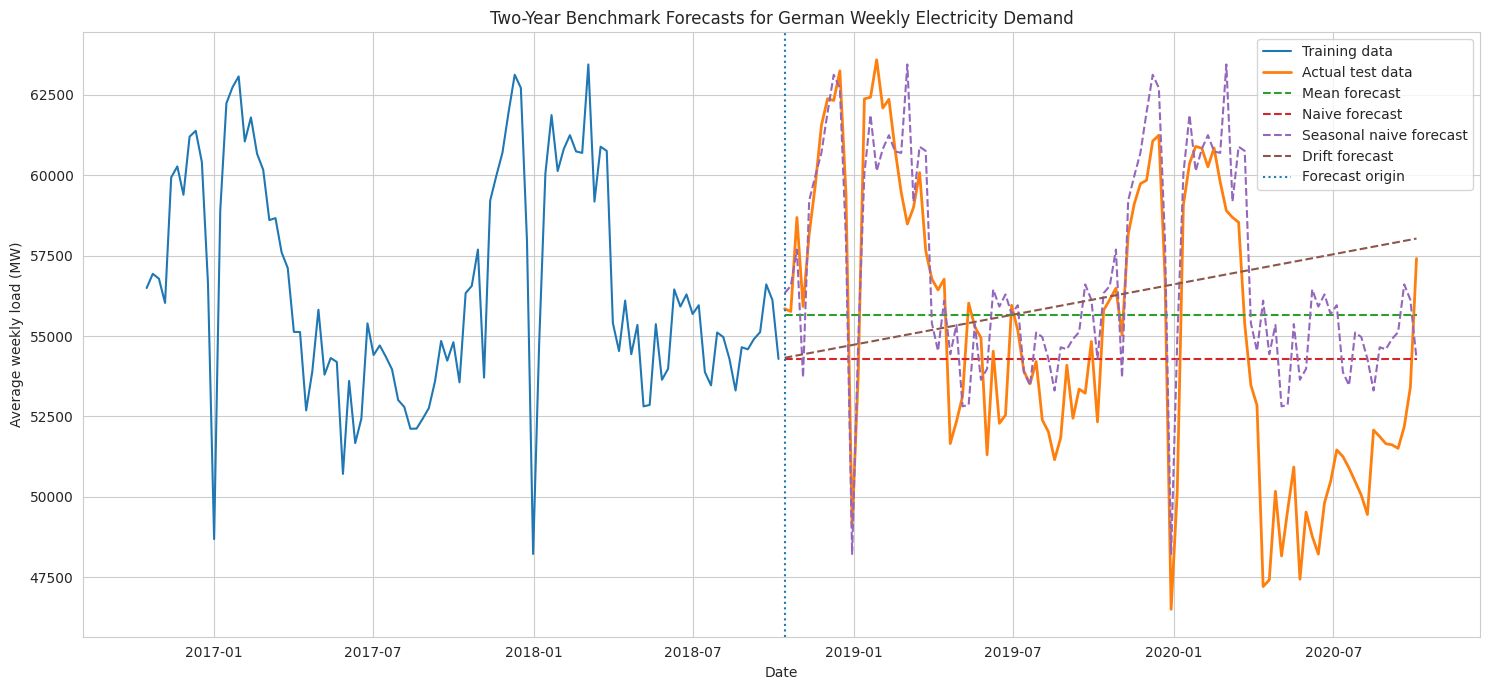

Training period: 2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00
Test period: 2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00
Forecast horizon: 104 weeks

Benchmark model results:
         Model      MAE     RMSE  MASE     Bias
Seasonal naive 2318.521 3006.761 1.732 1731.751
         Naive 3783.203 4459.109 2.827 -882.480
          Mean 3788.833 4397.300 2.831  481.006
         Drift 4339.891 5117.957 3.243 1006.802

Files created:
output/benchmark_forecast_comparison.png
output/benchmark_forecasts.csv
output/benchmark_metrics.csv


In [ ]:
# 2. Use a two-year forecast horizon

import numpy as np
from pathlib import Path

# Define output directory and create if it doesn't exist
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

forecast_horizon = 104

train = weekly.iloc[:-forecast_horizon]
test = weekly.iloc[-forecast_horizon:]

h = len(test)
forecast_index = test.index

# 3. Benchmark forecasting models

# Mean forecast: all future values equal the training mean
mean_forecast = pd.Series(
    np.repeat(train.mean(), h),
    index=forecast_index,
    name="Mean"
)

# Naive forecast: all future values equal the final training observation
naive_forecast = pd.Series(
    np.repeat(train.iloc[-1], h),
    index=forecast_index,
    name="Naive"
)

# Seasonal naive forecast:
# each week is forecast using the observation from 52 weeks earlier
season_length = 52
seasonal_values = np.resize(train.iloc[-season_length:].values, h)

seasonal_naive_forecast = pd.Series(
    seasonal_values,
    index=forecast_index,
    name="Seasonal naive"
)

# Drift forecast:
# extend a straight line between the first and final training observations
steps = np.arange(1, h + 1)

drift_values = (
    train.iloc[-1]
    + steps * (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
)

drift_forecast = pd.Series(
    drift_values,
    index=forecast_index,
    name="Drift"
)

# Combine forecasts
forecast_df = pd.DataFrame({
    "Actual": test,
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal naive": seasonal_naive_forecast,
    "Drift": drift_forecast
})

# 4. Accuracy measures

def mae(actual, forecast):
    return np.mean(np.abs(actual - forecast))

def rmse(actual, forecast):
    return np.sqrt(np.mean((actual - forecast) ** 2))

def bias(actual, forecast):
    # Positive value means the model over-forecasts on average
    return np.mean(forecast - actual)

def mase(actual, forecast, training, seasonality=52):
    scale = np.mean(
        np.abs(
            training.iloc[seasonality:].values
            - training.iloc[:-seasonality].values
        )
    )
    return mae(actual, forecast) / scale

metrics = []

for model_name in ["Mean", "Naive", "Seasonal naive", "Drift"]:
    pred = forecast_df[model_name]

    metrics.append({
        "Model": model_name,
        "MAE": mae(test, pred),
        "RMSE": rmse(test, pred),
        "MASE": mase(test, pred, train, seasonality=52),
        "Bias": bias(test, pred)
    })

metrics_df = (
    pd.DataFrame(metrics)
    .sort_values("MASE")
    .reset_index(drop=True)
)

# 5. Plot training, test and benchmark forecasts

plt.figure(figsize=(15, 7))

# Show the final two years of training data to keep the plot readable
plot_train = train.iloc[-104:]

plt.plot(
    plot_train.index,
    plot_train,
    label="Training data",
    linewidth=1.5
)

plt.plot(
    test.index,
    test,
    label="Actual test data",
    linewidth=2
)

plt.plot(
    mean_forecast.index,
    mean_forecast,
    label="Mean forecast",
    linestyle="--"
)

plt.plot(
    naive_forecast.index,
    naive_forecast,
    label="Naive forecast",
    linestyle="--"
)

plt.plot(
    seasonal_naive_forecast.index,
    seasonal_naive_forecast,
    label="Seasonal naive forecast",
    linestyle="--"
)

plt.plot(
    drift_forecast.index,
    drift_forecast,
    label="Drift forecast",
    linestyle="--"
)

plt.axvline(
    test.index[0],
    linestyle=":",
    label="Forecast origin"
)

plt.title("Two-Year Benchmark Forecasts for German Weekly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average weekly load (MW)")
plt.legend()
plt.tight_layout()

plot_path = output_dir / "benchmark_forecast_comparison.png"
plt.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

# 6. Save outputs

forecast_path = output_dir / "benchmark_forecasts.csv"
metrics_path = output_dir / "benchmark_metrics.csv"

forecast_df.to_csv(forecast_path)
metrics_df.to_csv(metrics_path, index=False)

print("Training period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())
print("Forecast horizon:", h, "weeks")
print("\nBenchmark model results:")
print(metrics_df.round(3).to_string(index=False))
print("\nFiles created:")
print(plot_path)
print(forecast_path)
print(metrics_path)


#Part 3:

Define an autoregressive model: use SARIMA if you believe there to be a seasonal component (hint, use the statsmodel package).
Find the best model parameters: p,d,q(P,D<Q) using the AIC likelihood method discussed in class. You must loop over all possible parameter combinations for p=[0,6], d=[0,2] and q=[0,6]
Assess the model fit by inspecting the data-model residuals - i.e making another ACF plot on the model residuals and also inspecting the distribution of the residuals.
Forecast the last 2 years of the available data.
Test model performance predictions using e.g. rmse.
Add confidence intervals on forecasts

In [ ]:

# PART 3: Fast SARIMA model selection and forecasting


import itertools
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

#1. Prepare the weekly data

In [ ]:
weekly_series = weekly.dropna().sort_index()

print("Total weekly observations:", len(weekly_series))
print("Start date:", weekly_series.index.min())
print("End date:", weekly_series.index.max())

Total weekly observations: 301
Start date: 2015-01-04 00:00:00+00:00
End date: 2020-10-04 00:00:00+00:00


#2. Create the two-year train/test split

In [ ]:
forecast_horizon = 104

if len(weekly_series) <= forecast_horizon:
    raise ValueError(
        "The full weekly dataset is required. "
        f"Only {len(weekly_series)} observations were found."
    )

train = weekly_series.iloc[:-forecast_horizon]
test = weekly_series.iloc[-forecast_horizon:]

print("\nTraining observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())


Training observations: 197
Testing observations: 104
Training period: 2015-01-04 00:00:00+00:00 to 2018-10-07 00:00:00+00:00
Testing period: 2018-10-14 00:00:00+00:00 to 2020-10-04 00:00:00+00:00


#3. Search all required p, d, and q combinations

This tests:

p = 0–6
d = 0–2
q = 0–6

The seasonal structure is initially fixed at (0, 1, 0, 52) to make the search faster.

For the seasonal terms, testing every value from 0–6 for both P and Q would create more than 20,000 models and may take an extremely long time. The following uses common seasonal candidates while still testing every required p, d, and q combination.

In [ ]:
p_values = range(0, 7)
d_values = range(0, 3)
q_values = range(0, 7)

orders = list(
    itertools.product(
        p_values,
        d_values,
        q_values
    )
)

print("Number of p,d,q combinations:", len(orders))

stage1_results = []

best_aic = np.inf
best_order = None

start_time = time.time()

for number, order in enumerate(orders, start=1):

    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=(0, 1, 0, 52),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False,
            method="lbfgs",
            maxiter=40
        )

        stage1_results.append({
            "order": order,
            "seasonal_order": (0, 1, 0, 52),
            "AIC": fitted_model.aic
        })

        if np.isfinite(fitted_model.aic) and fitted_model.aic < best_aic:
            best_aic = fitted_model.aic
            best_order = order

    except Exception:
        continue

    if number % 20 == 0:
        elapsed = (time.time() - start_time) / 60

        print(
            f"Completed {number}/{len(orders)} models | "
            f"Best order: {best_order} | "
            f"Best AIC: {best_aic:.2f} | "
            f"Time: {elapsed:.1f} minutes"
        )

if best_order is None:
    raise RuntimeError("No SARIMA model was fitted successfully.")

stage1_results = (
    pd.DataFrame(stage1_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("\nBest non-seasonal order:", best_order)
print("Stage 1 best AIC:", round(best_aic, 3))

print("\nTop Stage 1 models:")
print(stage1_results.head(10))

Number of p,d,q combinations: 147
Completed 20/147 models | Best order: (0, 1, 6) | Best AIC: 2433.27 | Time: 0.5 minutes
Completed 40/147 models | Best order: (0, 1, 6) | Best AIC: 2433.27 | Time: 1.2 minutes
Completed 60/147 models | Best order: (2, 1, 6) | Best AIC: 2428.23 | Time: 2.2 minutes
Completed 80/147 models | Best order: (2, 1, 6) | Best AIC: 2428.23 | Time: 3.4 minutes
Completed 100/147 models | Best order: (2, 1, 6) | Best AIC: 2428.23 | Time: 4.9 minutes
Completed 120/147 models | Best order: (2, 1, 6) | Best AIC: 2428.23 | Time: 6.6 minutes
Completed 140/147 models | Best order: (2, 1, 6) | Best AIC: 2428.23 | Time: 8.5 minutes

Best non-seasonal order: (2, 1, 6)
Stage 1 best AIC: 2428.232

Top Stage 1 models:
       order seasonal_order          AIC
0  (2, 1, 6)  (0, 1, 0, 52)  2428.232365
1  (4, 1, 6)  (0, 1, 0, 52)  2428.294159
2  (3, 1, 6)  (0, 1, 0, 52)  2429.630186
3  (5, 1, 6)  (0, 1, 0, 52)  2433.250915
4  (0, 1, 6)  (0, 1, 0, 52)  2433.267777
5  (6, 1, 6)  (0,

#4. Search a focused set of seasonal parameters

In [ ]:
seasonal_orders = [
    (0, 1, 0, 52),
    (0, 1, 0, 52),
    (0, 1, 0, 52),
    (0, 1, 0, 52),
    (0, 1, 0, 52),
    (0, 1, 0, 52),
    (0, 1, 0, 52),
    (0, 1, 0, 52)
]

seasonal_results = []

best_seasonal_aic = np.inf
best_seasonal_order = None

for seasonal_order in seasonal_orders:

    try:
        model = SARIMAX(
            train,
            order=best_order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False,
            method="lbfgs",
            maxiter=60
        )

        seasonal_results.append({
            "order": best_order,
            "seasonal_order": seasonal_order,
            "AIC": fitted_model.aic
        })

        if (
            np.isfinite(fitted_model.aic)
            and fitted_model.aic < best_seasonal_aic
        ):
            best_seasonal_aic = fitted_model.aic
            best_seasonal_order = seasonal_order

    except Exception:
        continue

if best_seasonal_order is None:
    raise RuntimeError("No seasonal SARIMA model was fitted successfully.")

seasonal_results = (
    pd.DataFrame(seasonal_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

print("\nBest SARIMA order:", best_order)
print("Best seasonal order:", best_seasonal_order)
print("Best AIC:", round(best_seasonal_aic, 3))

print("\nSeasonal model comparison:")
print(seasonal_results)


Best SARIMA order: (2, 1, 6)
Best seasonal order: (0, 1, 0, 52)
Best AIC: 2428.232

Seasonal model comparison:
       order seasonal_order          AIC
0  (2, 1, 6)  (0, 1, 0, 52)  2428.232365
1  (2, 1, 6)  (0, 1, 0, 52)  2428.232365
2  (2, 1, 6)  (0, 1, 0, 52)  2428.232365
3  (2, 1, 6)  (0, 1, 0, 52)  2428.232365
4  (2, 1, 6)  (0, 1, 0, 52)  2428.232365
5  (2, 1, 6)  (0, 1, 0, 52)  2428.232365
6  (2, 1, 6)  (0, 1, 0, 52)  2428.232365
7  (2, 1, 6)  (0, 1, 0, 52)  2428.232365


#5. Fit the final model

In [ ]:
final_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_model_fit = final_model.fit(
    disp=False,
    method="lbfgs",
    maxiter=200
)

print(final_model_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             load_mw   No. Observations:                  197
Model:             SARIMAX(2, 1, 6)x(0, 1, [], 52)   Log Likelihood               -1205.116
Date:                             Wed, 15 Jul 2026   AIC                           2428.232
Time:                                     20:18:44   BIC                           2454.512
Sample:                                 01-04-2015   HQIC                          2438.912
                                      - 10-07-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4967      0.075     -6.620      0.000      -0.644      -0.350
ar.L2         -0.8003      

#Inspect the model residuals

In [ ]:
residuals = final_model_fit.resid.dropna()

# Remove initial residuals affected by model initialisation
burn_in = max(
    getattr(final_model_fit, "loglikelihood_burn", 0),
    52
)

if len(residuals) > burn_in:
    residuals = residuals.iloc[burn_in:]

print("\nResidual summary:")
print(residuals.describe())


Residual summary:
count     137.000000
mean      -45.362445
std      1605.147139
min     -4704.940878
25%      -917.051720
50%       -83.423949
75%       818.365697
max      5685.328518
dtype: float64


#Residual ACF

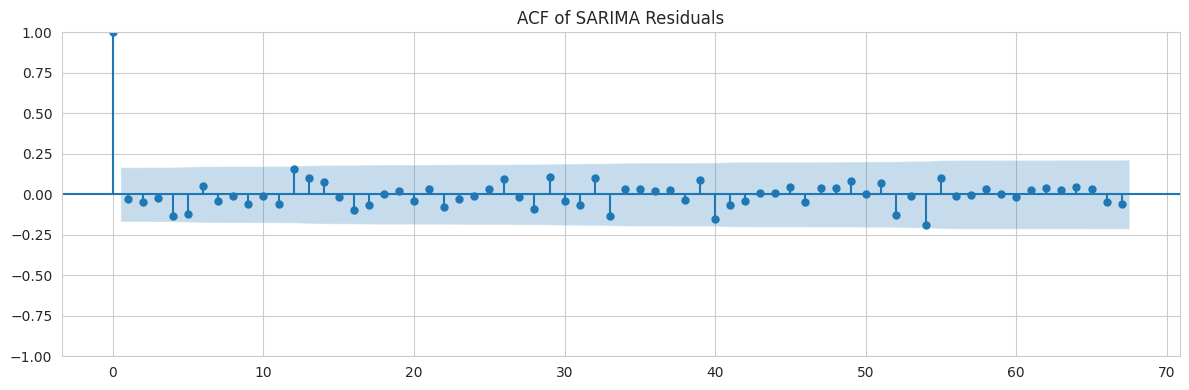

In [ ]:
maximum_lags = min(
    104,
    max(10, len(residuals) // 2 - 1)
)

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(
    residuals,
    lags=maximum_lags,
    ax=ax
)

ax.set_title("ACF of SARIMA Residuals")
plt.tight_layout()
plt.show()

#Residual distribution

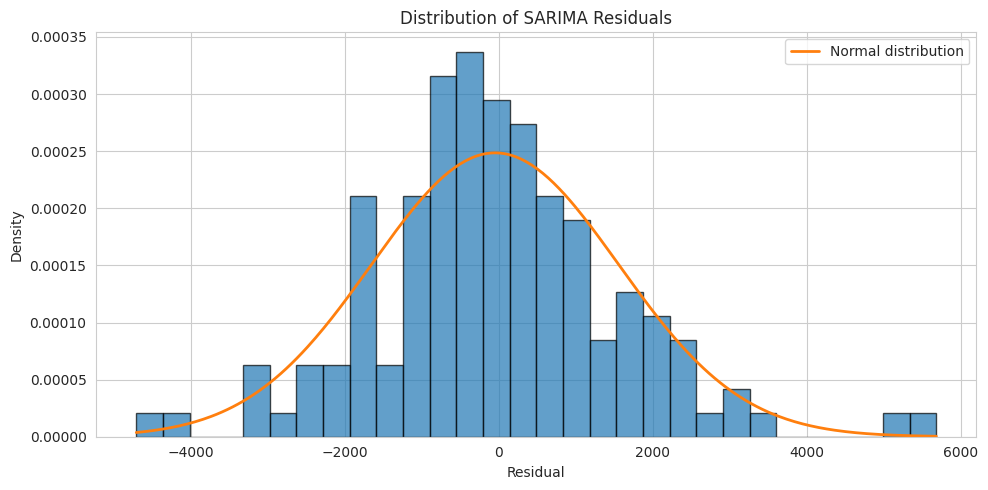

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    residuals,
    bins=30,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

x_values = np.linspace(
    residuals.min(),
    residuals.max(),
    300
)

normal_density = stats.norm.pdf(
    x_values,
    loc=residuals.mean(),
    scale=residuals.std()
)

plt.plot(
    x_values,
    normal_density,
    linewidth=2,
    label="Normal distribution"
)

plt.title("Distribution of SARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

##Q-Q plot

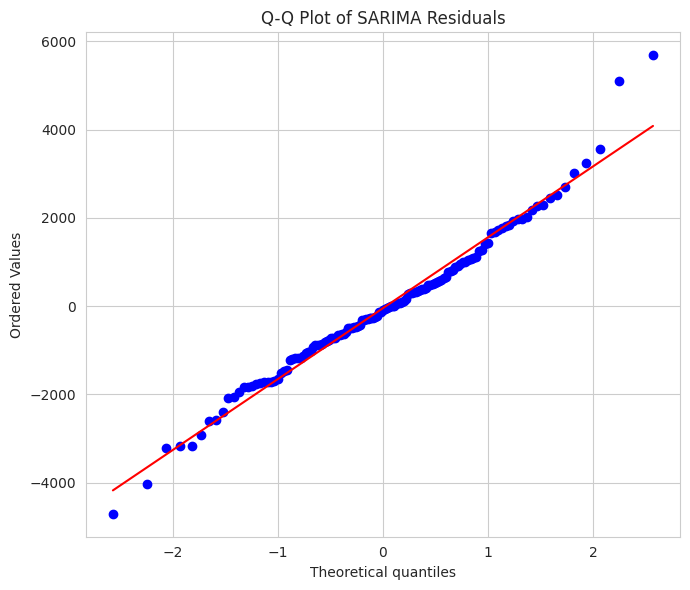

In [ ]:
plt.figure(figsize=(7, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of SARIMA Residuals")
plt.tight_layout()
plt.show()

In [ ]:
#Ljung–Box residual test

ljung_box = acorr_ljungbox(
    residuals,
    lags=[10, 20, 52],
    return_df=True
)

print("\nLjung-Box test:")
print(ljung_box)


Ljung-Box test:
      lb_stat  lb_pvalue
10   6.387446   0.781729
20  15.671510   0.736783
52  44.309920   0.766862


A Ljung–Box p-value above 0.05 suggests that there is no significant remaining autocorrelation at that lag.

#Forecast the final two years

In [ ]:
forecast_object = final_model_fit.get_forecast(
    steps=len(test)
)

forecast = forecast_object.predicted_mean
forecast.index = test.index

confidence_intervals = forecast_object.conf_int(
    alpha=0.05
)

confidence_intervals.index = test.index

lower_interval = confidence_intervals.iloc[:, 0]
upper_interval = confidence_intervals.iloc[:, 1]

#Calculate forecast performance

In [ ]:
actual_values = test.to_numpy()
forecast_values = forecast.to_numpy()

rmse = np.sqrt(
    np.mean(
        (actual_values - forecast_values) ** 2
    )
)

mae = np.mean(
    np.abs(
        actual_values - forecast_values
    )
)

bias = np.mean(
    forecast_values - actual_values
)

print("\nForecast performance")
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print("Bias:", round(bias, 3))


Forecast performance
RMSE: 4652.24
MAE: 3834.35
Bias: 3697.876


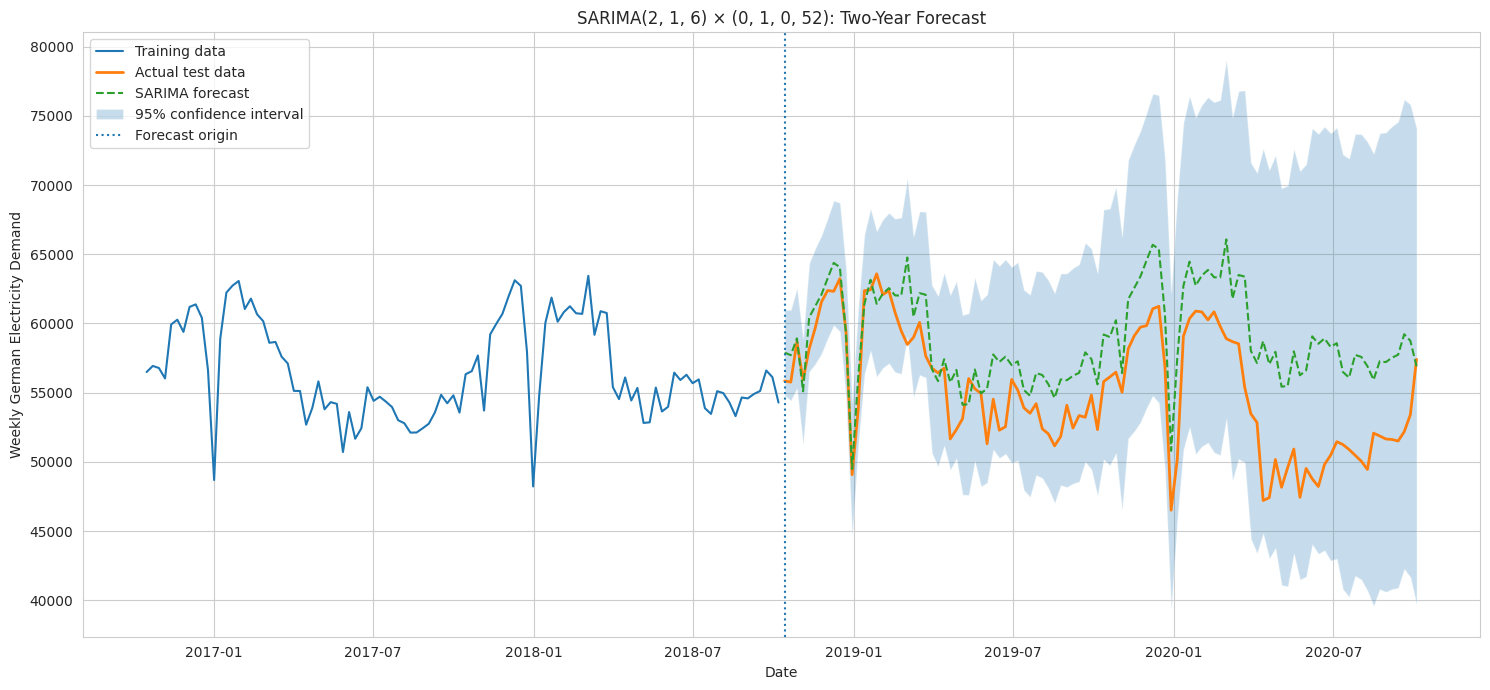

In [ ]:
#Plot the forecast with confidence intervals
plt.figure(figsize=(15, 7))

# Show the final two years of training data
plt.plot(
    train.iloc[-104:].index,
    train.iloc[-104:],
    label="Training data"
)

plt.plot(
    test.index,
    test,
    label="Actual test data",
    linewidth=2
)

plt.plot(
    forecast.index,
    forecast,
    label="SARIMA forecast",
    linestyle="--"
)

plt.fill_between(
    test.index,
    lower_interval,
    upper_interval,
    alpha=0.25,
    label="95% confidence interval"
)

plt.axvline(
    test.index[0],
    linestyle=":",
    label="Forecast origin"
)

plt.title(
    f"SARIMA{best_order} × "
    f"{best_seasonal_order}: Two-Year Forecast"
)

plt.xlabel("Date")
plt.ylabel("Weekly German Electricity Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Store the final results
sarima_forecast_results = pd.DataFrame(
    {
        "Actual": test,
        "SARIMA Forecast": forecast,
        "Lower 95% CI": lower_interval,
        "Upper 95% CI": upper_interval
    }
)

print(sarima_forecast_results.head())

                                 Actual  SARIMA Forecast  Lower 95% CI  \
timestamp                                                                
2018-10-14 00:00:00+00:00  55848.940476     57891.438182  54807.665363   
2018-10-21 00:00:00+00:00  55762.125000     57710.564425  54433.221733   
2018-10-28 00:00:00+00:00  58684.714286     58925.735254  55301.265951   
2018-11-04 00:00:00+00:00  55917.589286     55102.703187  51274.229069   
2018-11-11 00:00:00+00:00  58163.470238     60438.554162  56509.833531   

                           Upper 95% CI  
timestamp                                
2018-10-14 00:00:00+00:00  60975.211001  
2018-10-21 00:00:00+00:00  60987.907117  
2018-10-28 00:00:00+00:00  62550.204556  
2018-11-04 00:00:00+00:00  58931.177304  
2018-11-11 00:00:00+00:00  64367.274793  


#Part 4:

Add in an additional weekly variable of Temperature to be used as an exogenous variable to make an 'explanatory' or 'conditional' forecast. This can be retrieved from https://archive-api.open-meteo.com/v1/archive
Use Berlin as a representative location for German temperature. The file "A1_temperature_features" will help you here. Temperature features are not known in advance unless they come from a weather forecast. If we use observed future temperature in the test set, this should be described as an explanatory or conditional forecast rather than a true operational forecast

Add this variable to make the SARIMAX forecast and model and make a weekly forecast. hint: the file 'A1_exogenous_regressors' will show you how these can be added to the model so that we now have the 'X' in SARIMAX model.

In [ ]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
weekly_series = weekly.dropna().sort_index()

# Remove timezone information so that it aligns with temperature dates
weekly_series.index = pd.to_datetime(weekly_series.index)

if weekly_series.index.tz is not None:
    weekly_series.index = weekly_series.index.tz_convert(None)

weekly_series.index = weekly_series.index.normalize()

print("Weekly load observations:", len(weekly_series))
print("Start:", weekly_series.index.min())
print("End:", weekly_series.index.max())

Weekly load observations: 301
Start: 2015-01-04 00:00:00
End: 2020-10-04 00:00:00


In [ ]:
def get_open_meteo_temperature(
    start_date,
    end_date,
    latitude=52.52,
    longitude=13.41
):
    """
    Download daily mean temperature for Berlin from
    the Open-Meteo historical weather API.
    """

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean",
        "timezone": "Europe/Berlin"
    }

    response = requests.get(
        url,
        params=params,
        timeout=60
    )

    response.raise_for_status()

    daily_data = response.json()["daily"]

    temperature = pd.DataFrame({
        "date": pd.to_datetime(daily_data["time"]),
        "temperature_2m_mean": daily_data["temperature_2m_mean"]
    })

    temperature["temperature_2m_mean"] = pd.to_numeric(
        temperature["temperature_2m_mean"],
        errors="coerce"
    )

    temperature = temperature.set_index("date").sort_index()

    return temperature

In [ ]:
#Retrieve temperature for the electricity-demand period
temp_daily = get_open_meteo_temperature(
    start_date=str(weekly_series.index.min().date()),
    end_date=str(weekly_series.index.max().date())
)

print(temp_daily.head())
print(temp_daily.tail())
print("Missing daily temperature:", temp_daily.isna().sum())

            temperature_2m_mean
date                           
2015-01-04                  3.0
2015-01-05                  2.7
2015-01-06                  1.2
2015-01-07                  2.1
2015-01-08                  3.1
            temperature_2m_mean
date                           
2020-09-30                 12.8
2020-10-01                 12.9
2020-10-02                 14.2
2020-10-03                 16.7
2020-10-04                 14.1
Missing daily temperature: temperature_2m_mean    0
dtype: int64


In [ ]:
#Convert daily temperature to weekly temperature
#Use the same week-ending rule as the electricity series.
temp_weekly = (
    temp_daily["temperature_2m_mean"]
    .resample("W-SUN")
    .mean()
    .rename("temp_mean")
)

print(temp_weekly.head())
print("Weekly temperature observations:", len(temp_weekly))

date
2015-01-04    3.000000
2015-01-11    3.885714
2015-01-18    4.900000
2015-01-25    0.028571
2015-02-01    1.414286
Freq: W-SUN, Name: temp_mean, dtype: float64
Weekly temperature observations: 301


In [ ]:
#Combine weekly electricity and temperature data

feature_df = pd.concat(
    [
        weekly_series.rename("DE_Load"),
        temp_weekly
    ],
    axis=1
)

# Interpolate any small gaps in the temperature series
feature_df["temp_mean"] = (
    feature_df["temp_mean"]
    .interpolate(method="time")
)

feature_df = feature_df.dropna()

print(feature_df.head())
print(feature_df.tail())
print(feature_df.isna().sum())
print("Combined observations:", len(feature_df))

                 DE_Load  temp_mean
2015-01-04  47233.739583   3.000000
2015-01-11  56191.101190   3.885714
2015-01-18  57672.678571   4.900000
2015-01-25  58613.303571   0.028571
2015-02-01  58734.029762   1.414286
                 DE_Load  temp_mean
2020-09-06  51617.744048  15.985714
2020-09-13  51507.630952  16.442857
2020-09-20  52181.327381  17.242857
2020-09-27  53411.934524  15.014286
2020-10-04  57410.319444  13.814286
DE_Load      0
temp_mean    0
dtype: int64
Combined observations: 301


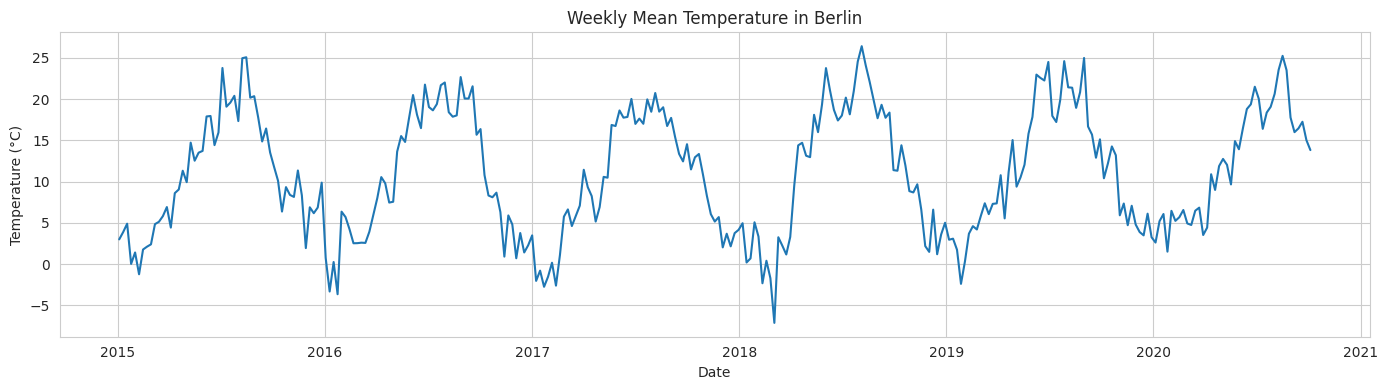

In [ ]:
#Plot weekly temperature

plt.figure(figsize=(14, 4))

plt.plot(
    feature_df.index,
    feature_df["temp_mean"]
)

plt.title("Weekly Mean Temperature in Berlin")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Split load and temperature into training and test sets
#The final 104 weeks are used as the two-year test period.

test_weeks = 104

y = feature_df["DE_Load"]

X = feature_df[
    ["temp_mean"]
]

y_train = y.iloc[:-test_weeks]
y_test = y.iloc[-test_weeks:]

X_train = X.iloc[:-test_weeks]
X_test = X.iloc[-test_weeks:]

print("Load training shape:", y_train.shape)
print("Load testing shape:", y_test.shape)

print("Temperature training shape:", X_train.shape)
print("Temperature testing shape:", X_test.shape)

Load training shape: (197,)
Load testing shape: (104,)
Temperature training shape: (197, 1)
Temperature testing shape: (104, 1)


In [ ]:
#Fit the SARIMAX model with temperature

#Temperature is supplied through the exog argument.

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=order,
    seasonal_order=seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(
    disp=False,
    maxiter=200
)

print(sarimax_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             DE_Load   No. Observations:                  197
Model:             SARIMAX(6, 2, 6)x(0, 1, [], 52)   Log Likelihood               -1206.928
Date:                             Wed, 15 Jul 2026   AIC                           2443.856
Time:                                     20:35:09   BIC                           2487.546
Sample:                                 01-04-2015   HQIC                          2461.611
                                      - 10-07-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.2594      2.682     -0.470      0.639      -6.517       3.998
temp_mean    -93.3632     3

In [ ]:
#Forecast the final two years

#The observed test-period temperature is passed to the forecast through exog=X_test.

sarimax_forecast_object = sarimax_fit.get_forecast(
    steps=len(y_test),
    exog=X_test
)

sarimax_forecast = sarimax_forecast_object.predicted_mean
sarimax_forecast.index = y_test.index

In [ ]:
#Extract confidence intervals

confidence_intervals = sarimax_forecast_object.conf_int(
    alpha=0.05
)

confidence_intervals.index = y_test.index

lower_interval = confidence_intervals.iloc[:, 0]
upper_interval = confidence_intervals.iloc[:, 1]

In [ ]:
#Calculate forecast accuracy
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        sarimax_forecast
    )
)

mae = mean_absolute_error(
    y_test,
    sarimax_forecast
)

bias = np.mean(
    sarimax_forecast.values - y_test.values
)

print("Conditional SARIMAX performance")
print("RMSE:", round(rmse, 3))
print("MAE:", round(mae, 3))
print("Bias:", round(bias, 3))

Conditional SARIMAX performance
RMSE: 22537.706
MAE: 16985.744
Bias: -16898.273


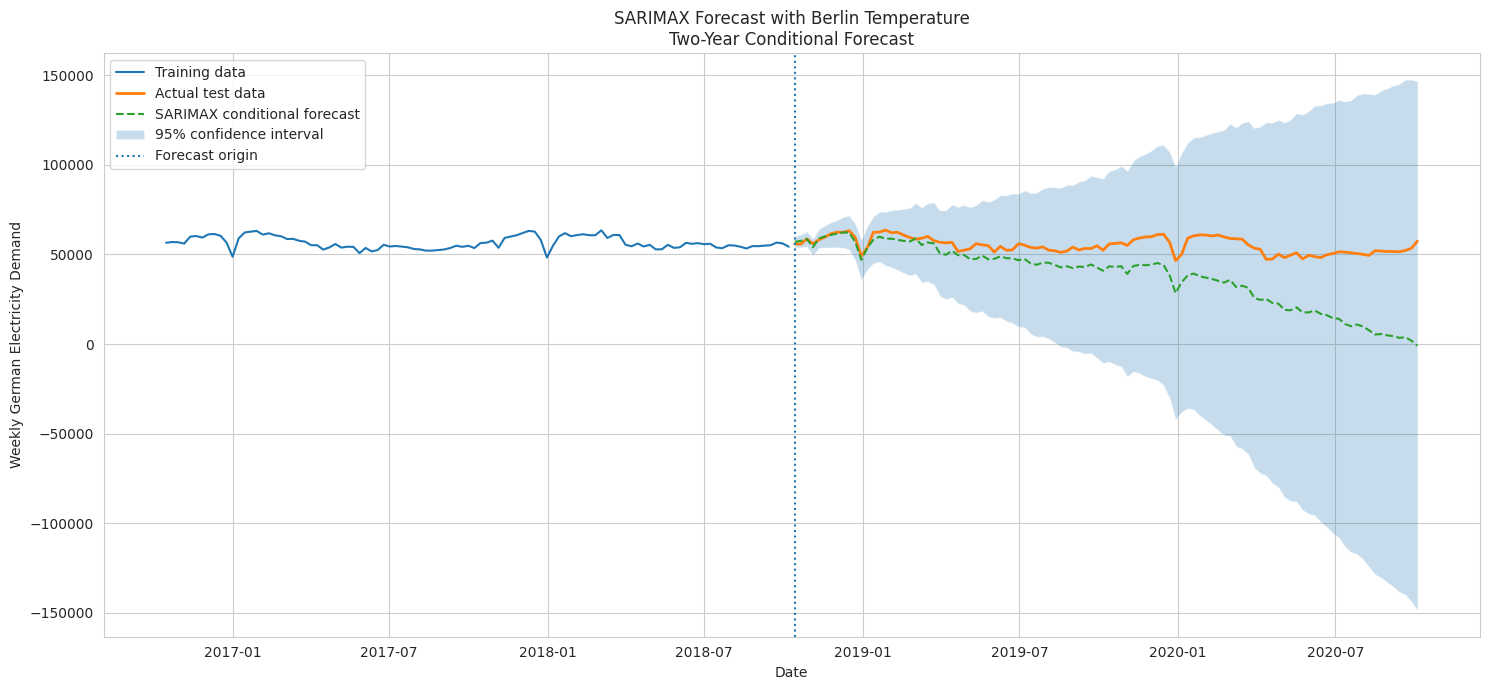

In [ ]:
#Plot the conditional forecast

plt.figure(figsize=(15, 7))

# Show the final two years of training data
plt.plot(
    y_train.iloc[-104:].index,
    y_train.iloc[-104:],
    label="Training data"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual test data",
    linewidth=2
)

plt.plot(
    sarimax_forecast.index,
    sarimax_forecast,
    label="SARIMAX conditional forecast",
    linestyle="--"
)

plt.fill_between(
    y_test.index,
    lower_interval,
    upper_interval,
    alpha=0.25,
    label="95% confidence interval"
)

plt.axvline(
    y_test.index[0],
    linestyle=":",
    label="Forecast origin"
)

plt.title(
    "SARIMAX Forecast with Berlin Temperature\n"
    "Two-Year Conditional Forecast"
)

plt.xlabel("Date")
plt.ylabel("Weekly German Electricity Demand")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Save the forecast results

sarimax_temperature_results = pd.DataFrame({
    "Actual": y_test,
    "SARIMAX Temperature Forecast": sarimax_forecast,
    "Lower 95% CI": lower_interval,
    "Upper 95% CI": upper_interval,
    "Observed Berlin Temperature": X_test["temp_mean"]
})

sarimax_temperature_results.to_csv(
    "sarimax_temperature_forecast.csv"
)

print(sarimax_temperature_results.head())

                  Actual  SARIMAX Temperature Forecast  Lower 95% CI  \
2018-10-14  55848.940476                  57068.274263  53963.510714   
2018-10-21  55762.125000                  57547.303091  54061.424975   
2018-10-28  58684.714286                  58590.871598  54439.711877   
2018-11-04  55917.589286                  54062.156624  49415.499174   
2018-11-11  58163.470238                  58915.702675  53691.203394   

            Upper 95% CI  Observed Berlin Temperature  
2018-10-14  60173.037812                    14.400000  
2018-10-21  61033.181207                    11.957143  
2018-10-28  62742.031318                     8.842857  
2018-11-04  58708.814074                     8.685714  
2018-11-11  64140.201957                     9.671429  


Berlin weekly mean temperature was added as an exogenous variable in the SARIMAX model. The final 104 weeks were forecast using the observed temperature values from the test period. Since these future temperatures would not have been known at the forecast origin, the results represent an explanatory or conditional forecast rather than a true operational forecast.

#Part 5:

Model the weekly electricity load and temperature data with a feature-based regression model.
For example, Random Forest or Gradient Boosting Regressor.
Forecast the last 2 years of the avalailable data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
#Prepare weekly load and temperature data

# feature_df should already have been created in Part 4.

# Support either load_gw or DE_Load as the target column
if "load_gw" in feature_df.columns:
    target_column = "load_gw"
elif "DE_Load" in feature_df.columns:
    target_column = "DE_Load"
else:
    raise KeyError(
        "feature_df must contain either 'load_gw' or 'DE_Load'."
    )

data = feature_df.copy().sort_index()

# Create heating and cooling features if they are not already present
if "heating_degree" not in data.columns:
    data["heating_degree"] = np.maximum(
        18 - data["temp_mean"],
        0
    )

if "cooling_degree" not in data.columns:
    data["cooling_degree"] = np.maximum(
        data["temp_mean"] - 18,
        0
    )

data = data[
    [
        target_column,
        "temp_mean",
        "heating_degree",
        "cooling_degree"
    ]
].dropna()

print("Total observations:", len(data))
print("Start date:", data.index.min())
print("End date:", data.index.max())

Total observations: 301
Start date: 2015-01-04 00:00:00
End date: 2020-10-04 00:00:00


In [ ]:
#Split the final two years

test_weeks = 104

if len(data) <= test_weeks + 52:
    raise ValueError(
        "There are not enough observations for a 104-week test set "
        "and a 52-week lag."
    )

train_data = data.iloc[:-test_weeks].copy()
test_data = data.iloc[-test_weeks:].copy()

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

Training observations: 197
Testing observations: 104


In [ ]:
#Create training features

def create_training_features(dataframe, target):

    features = pd.DataFrame(index=dataframe.index)

    load = dataframe[target]

    # Temperature variables
    features["temp_mean"] = dataframe["temp_mean"]
    features["heating_degree"] = dataframe["heating_degree"]
    features["cooling_degree"] = dataframe["cooling_degree"]

    # Calendar variables
    week_number = (
        dataframe.index.isocalendar().week
        .astype(int)
        .to_numpy()
    )

    features["week_sin"] = np.sin(
        2 * np.pi * week_number / 52
    )

    features["week_cos"] = np.cos(
        2 * np.pi * week_number / 52
    )

    # Load lag variables
    features["lag_1"] = load.shift(1)
    features["lag_2"] = load.shift(2)
    features["lag_4"] = load.shift(4)
    features["lag_13"] = load.shift(13)
    features["lag_52"] = load.shift(52)

    # Rolling statistics use only previous load values
    features["rolling_mean_4"] = (
        load.shift(1).rolling(4).mean()
    )

    features["rolling_mean_13"] = (
        load.shift(1).rolling(13).mean()
    )

    features["rolling_mean_52"] = (
        load.shift(1).rolling(52).mean()
    )

    features["rolling_std_4"] = (
        load.shift(1).rolling(4).std()
    )

    features["rolling_std_13"] = (
        load.shift(1).rolling(13).std()
    )

    features["target"] = load

    return features.dropna()

In [ ]:
#Build the training table

training_table = create_training_features(
    train_data,
    target_column
)

X_train = training_table.drop(
    columns="target"
)

y_train = training_table["target"]

feature_columns = X_train.columns.tolist()

print("Training feature shape:", X_train.shape)
print("Features:", feature_columns)

Training feature shape: (145, 15)
Features: ['temp_mean', 'heating_degree', 'cooling_degree', 'week_sin', 'week_cos', 'lag_1', 'lag_2', 'lag_4', 'lag_13', 'lag_52', 'rolling_mean_4', 'rolling_mean_13', 'rolling_mean_52', 'rolling_std_4', 'rolling_std_13']


In [ ]:
#Fit Gradient Boosting Regressor

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=5,
    loss="huber",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Gradient Boosting model fitted.")

Gradient Boosting model fitted.


In [ ]:
# Function for recursive forecast features

def create_forecast_features(
    forecast_date,
    temperature,
    heating_degree,
    cooling_degree,
    load_history,
    feature_order
):

    week_number = int(
        forecast_date.isocalendar().week
    )

    values = {
        "temp_mean": temperature,
        "heating_degree": heating_degree,
        "cooling_degree": cooling_degree,

        "week_sin": np.sin(
            2 * np.pi * week_number / 52
        ),

        "week_cos": np.cos(
            2 * np.pi * week_number / 52
        ),

        "lag_1": load_history[-1],
        "lag_2": load_history[-2],
        "lag_4": load_history[-4],
        "lag_13": load_history[-13],
        "lag_52": load_history[-52],

        "rolling_mean_4": np.mean(
            load_history[-4:]
        ),

        "rolling_mean_13": np.mean(
            load_history[-13:]
        ),

        "rolling_mean_52": np.mean(
            load_history[-52:]
        ),

        "rolling_std_4": np.std(
            load_history[-4:],
            ddof=1
        ),

        "rolling_std_13": np.std(
            load_history[-13:],
            ddof=1
        )
    }

    row = pd.DataFrame(
        [values],
        index=[forecast_date]
    )

    return row[feature_order]

In [ ]:
#Forecast the last 104 weeks

# Start with actual training-period load values
load_history = train_data[target_column].tolist()

predictions = []

for forecast_date, row in test_data.iterrows():

    X_next = create_forecast_features(
        forecast_date=forecast_date,
        temperature=row["temp_mean"],
        heating_degree=row["heating_degree"],
        cooling_degree=row["cooling_degree"],
        load_history=load_history,
        feature_order=feature_columns
    )

    predicted_load = model.predict(X_next)[0]

    predictions.append(predicted_load)

    # Use the prediction for future lag values
    load_history.append(predicted_load)

In [ ]:
# Store predictions

forecast = pd.Series(
    predictions,
    index=test_data.index,
    name="Gradient_Boosting_Forecast"
)

forecast_results = pd.DataFrame({
    "Actual": test_data[target_column],
    "Gradient Boosting Forecast": forecast,
    "Berlin Temperature": test_data["temp_mean"]
})

print(forecast_results.head())

                  Actual  Gradient Boosting Forecast  Berlin Temperature
2018-10-14  55848.940476                55954.883886           14.400000
2018-10-21  55762.125000                57513.720667           11.957143
2018-10-28  58684.714286                58208.186417            8.842857
2018-11-04  55917.589286                54433.866692            8.685714
2018-11-11  58163.470238                58396.860603            9.671429


In [ ]:
#  Evaluate model performance

actual = forecast_results["Actual"]
predicted = forecast_results["Gradient Boosting Forecast"]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

bias = np.mean(
    predicted - actual
)

# Seasonal MASE scale
training_load = train_data[target_column]

mase_scale = np.mean(
    np.abs(
        training_load.iloc[52:].values
        - training_load.iloc[:-52].values
    )
)

mase = mae / mase_scale

print("\nGradient Boosting performance")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("MASE:", round(mase, 3))
print("Bias:", round(bias, 3))


Gradient Boosting performance
MAE : 2572.576
RMSE: 3432.984
MASE: 1.922
Bias: 2079.209


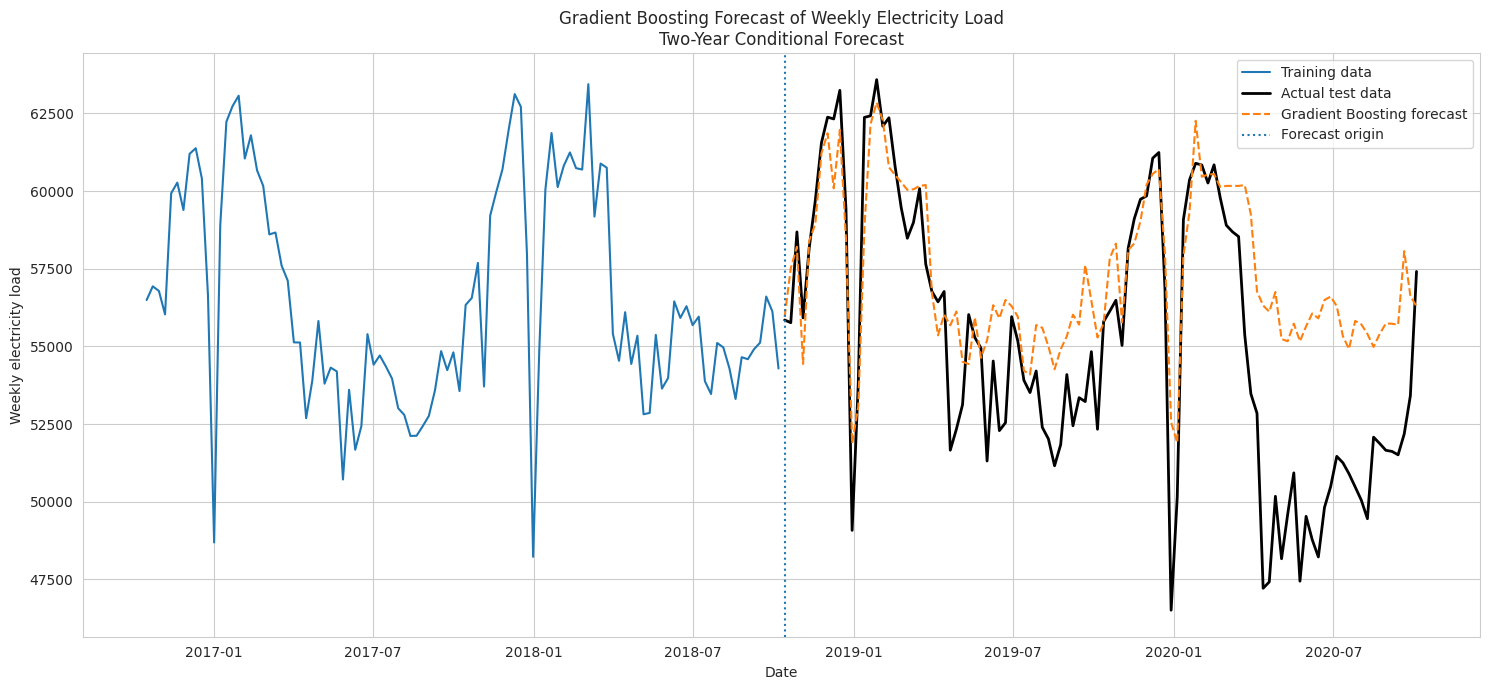

In [ ]:
# Plot the two-year forecast

plt.figure(figsize=(15, 7))

plt.plot(
    train_data.iloc[-104:].index,
    train_data.iloc[-104:][target_column],
    label="Training data"
)

plt.plot(
    test_data.index,
    test_data[target_column],
    label="Actual test data",
    color="black",
    linewidth=2
)

plt.plot(
    forecast.index,
    forecast,
    label="Gradient Boosting forecast",
    linestyle="--"
)

plt.axvline(
    test_data.index[0],
    linestyle=":",
    label="Forecast origin"
)

plt.title(
    "Gradient Boosting Forecast of Weekly Electricity Load\n"
    "Two-Year Conditional Forecast"
)

plt.xlabel("Date")
plt.ylabel("Weekly electricity load")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

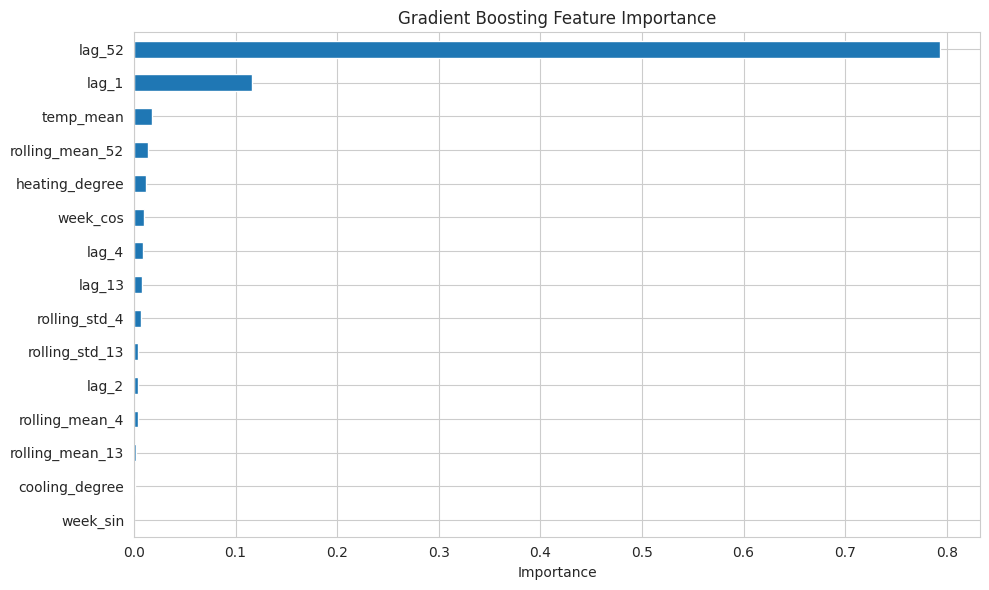

In [ ]:
#Plot feature importance

feature_importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values()

plt.figure(figsize=(10, 6))

feature_importance.plot(
    kind="barh"
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#Part 6:

Using hourly data, use and LSTM to model and forecast the data.
Conduct literature review around the use of LSTM for this task
Build model and hypertune the parameters and layer design
Forecast the last 2 years of the available data.
Compute appropriate evaluation metrics

In [ ]:
# !pip install tensorflow scikit-learn

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
# !pip install tensorflow scikit-learn

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [ ]:
#Load the hourly German electricity data
FILE_PATH = "time_series_60min_singleindex.csv"

LOAD_COLUMN = "DE_load_actual_entsoe_transparency"

df = pd.read_csv(
    FILE_PATH,
    usecols=[
        "utc_timestamp",
        LOAD_COLUMN
    ],
    parse_dates=["utc_timestamp"]
)

df = df.rename(
    columns={
        "utc_timestamp": "timestamp",
        LOAD_COLUMN: "load_mw"
    }
)

df = (
    df.set_index("timestamp")
    .sort_index()
)

# Keep data from 1 January 2015 onward
hourly_load = (
    df.loc["2015-01-01":, "load_mw"]
    .astype(float)
)

# Ensure a regular hourly frequency
hourly_load = hourly_load.asfreq("h")

# Fill any small gaps using time interpolation
hourly_load = (
    hourly_load
    .interpolate(method="time")
    .dropna()
)

print("Hourly observations:", len(hourly_load))
print("Start date:", hourly_load.index.min())
print("End date:", hourly_load.index.max())
print("Missing values:", hourly_load.isna().sum())

Hourly observations: 50400
Start date: 2015-01-01 00:00:00+00:00
End date: 2020-09-30 23:00:00+00:00
Missing values: 0


In [ ]:
#Create the two-year train/test split

# Two 365-day years of hourly observations
TEST_HOURS = 24 * 365 * 2

if len(hourly_load) <= TEST_HOURS:
    raise ValueError(
        "There are not enough observations for a two-year test set."
    )

train_full = hourly_load.iloc[:-TEST_HOURS].copy()
test = hourly_load.iloc[-TEST_HOURS:].copy()

print("Training observations:", len(train_full))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train_full.index.min(), "to", train_full.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training observations: 32880
Testing observations: 17520

Training period:
2015-01-01 00:00:00+00:00 to 2018-10-01 23:00:00+00:00

Testing period:
2018-10-02 00:00:00+00:00 to 2020-09-30 23:00:00+00:00


#Create hourly calendar features

The LSTM uses:

Scaled electricity load.
Hour-of-day sine and cosine.
Day-of-week sine and cosine.
Day-of-year sine and cosine.



In [ ]:
def make_calendar_features(index):
    """Create cyclical calendar features for an hourly index."""

    hour = index.hour.to_numpy()
    day_of_week = index.dayofweek.to_numpy()
    day_of_year = index.dayofyear.to_numpy()

    calendar = np.column_stack([
        np.sin(2 * np.pi * hour / 24),
        np.cos(2 * np.pi * hour / 24),

        np.sin(2 * np.pi * day_of_week / 7),
        np.cos(2 * np.pi * day_of_week / 7),

        np.sin(2 * np.pi * day_of_year / 365.25),
        np.cos(2 * np.pi * day_of_year / 365.25)
    ])

    return calendar.astype(np.float32)

In [ ]:
def make_feature_matrix(series, scaler):
    """Combine scaled load with cyclical calendar features."""

    scaled_load = scaler.transform(
        series.to_numpy().reshape(-1, 1)
    ).ravel()

    calendar = make_calendar_features(series.index)

    features = np.column_stack([
        scaled_load,
        calendar
    ])

    return features.astype(np.float32), scaled_load.astype(np.float32)

In [ ]:
LOOKBACK = 24 * 7
OUTPUT_HORIZON = 24

BATCH_SIZE = 128
TRAIN_STRIDE = 6
VALIDATION_STRIDE = 24

In [ ]:
def make_lstm_dataset(
    features,
    scaled_target,
    lookback,
    horizon,
    batch_size,
    sequence_stride=1,
    shuffle=False
):
    """
    Create an LSTM dataset.

    X shape:
        samples × lookback × features

    y shape:
        samples × forecast horizon
    """

    if len(features) < lookback + horizon:
        raise ValueError(
            "The series is too short for the selected "
            "lookback and forecast horizon."
        )

    # Each row contains the next horizon target observations
    targets = np.lib.stride_tricks.sliding_window_view(
        scaled_target[lookback:],
        window_shape=horizon
    )

    # Removing the final horizon values keeps X and y aligned
    input_data = features[:-horizon]

    dataset = tf.keras.utils.timeseries_dataset_from_array(
        data=input_data,
        targets=targets,
        sequence_length=lookback,
        sequence_stride=sequence_stride,
        shuffle=shuffle,
        seed=SEED,
        batch_size=batch_size
    )

    return dataset

In [ ]:
#Create a training and validation period

#The final 90 days of the training period are used for hyperparameter selection. The two-year test set remains untouched.

VALIDATION_HOURS = 24 * 90

tuning_train = train_full.iloc[:-VALIDATION_HOURS].copy()
validation = train_full.iloc[-VALIDATION_HOURS:].copy()

print("Tuning training observations:", len(tuning_train))
print("Validation observations:", len(validation))



Tuning training observations: 30720
Validation observations: 2160


In [ ]:
#Fit the scaler using only the tuning-training period

tuning_scaler = StandardScaler()

tuning_scaler.fit(
    tuning_train.to_numpy().reshape(-1, 1)
)


StandardScaler()

In [ ]:
tune_features, tune_target_scaled = make_feature_matrix(
    tuning_train,
    tuning_scaler
)

tune_dataset = make_lstm_dataset(
    features=tune_features,
    scaled_target=tune_target_scaled,
    lookback=LOOKBACK,
    horizon=OUTPUT_HORIZON,
    batch_size=BATCH_SIZE,
    sequence_stride=TRAIN_STRIDE,
    shuffle=True
)

In [ ]:
validation_context = pd.concat([
    tuning_train.iloc[-LOOKBACK:],
    validation
])

validation_features, validation_target_scaled = make_feature_matrix(
    validation_context,
    tuning_scaler
)

validation_dataset = make_lstm_dataset(
    features=validation_features,
    scaled_target=validation_target_scaled,
    lookback=LOOKBACK,
    horizon=OUTPUT_HORIZON,
    batch_size=BATCH_SIZE,
    sequence_stride=VALIDATION_STRIDE,
    shuffle=False
)

In [ ]:
#Define the LSTM model

NUMBER_OF_FEATURES = 7

In [ ]:
def build_lstm_model(
    units,
    number_of_layers,
    dropout,
    learning_rate
):
    """Build a one-layer or two-layer LSTM model."""

    model = Sequential()

    model.add(
        Input(
            shape=(LOOKBACK, NUMBER_OF_FEATURES)
        )
    )

    if number_of_layers == 1:

        model.add(
            LSTM(units)
        )

    elif number_of_layers == 2:

        model.add(
            LSTM(
                units,
                return_sequences=True
            )
        )

        model.add(
            Dropout(dropout)
        )

        model.add(
            LSTM(
                max(units // 2, 16)
            )
        )

    else:
        raise ValueError(
            "number_of_layers must be either 1 or 2."
        )

    model.add(
        Dropout(dropout)
    )

    model.add(
        Dense(
            32,
            activation="relu"
        )
    )

    # Predict the next 24 hours
    model.add(
        Dense(OUTPUT_HORIZON)
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate,
        clipnorm=1.0
    )

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

Hyperparameter and layer tuning

This compact search tests:

One and two LSTM layers.
32, 64 and 96 units.
Different dropout levels.
Different learning rates.

In [ ]:
candidate_models = [
    {
        "units": 32,
        "number_of_layers": 1,
        "dropout": 0.0,
        "learning_rate": 0.001
    },
    {
        "units": 64,
        "number_of_layers": 1,
        "dropout": 0.2,
        "learning_rate": 0.001
    },
    {
        "units": 64,
        "number_of_layers": 2,
        "dropout": 0.2,
        "learning_rate": 0.0005
    },
    {
        "units": 96,
        "number_of_layers": 2,
        "dropout": 0.3,
        "learning_rate": 0.0005
    }
]

In [ ]:
tuning_results = []

best_validation_loss = np.inf
best_parameters = None
best_epoch = None

for trial_number, parameters in enumerate(
    candidate_models,
    start=1
):

    print(
        f"\nTrial {trial_number}/{len(candidate_models)}"
    )
    print(parameters)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    candidate_model = build_lstm_model(
        units=parameters["units"],
        number_of_layers=parameters["number_of_layers"],
        dropout=parameters["dropout"],
        learning_rate=parameters["learning_rate"]
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=0.00001
        )
    ]

    history = candidate_model.fit(
        tune_dataset,
        validation_data=validation_dataset,
        epochs=20,
        callbacks=callbacks,
        verbose=1
    )

    trial_validation_loss = min(
        history.history["val_loss"]
    )

    trial_best_epoch = (
        np.argmin(history.history["val_loss"]) + 1
    )

    tuning_results.append({
        **parameters,
        "best_epoch": trial_best_epoch,
        "validation_mse": trial_validation_loss,
        "validation_rmse_scaled": np.sqrt(
            trial_validation_loss
        )
    })

    if trial_validation_loss < best_validation_loss:

        best_validation_loss = trial_validation_loss
        best_parameters = parameters.copy()
        best_epoch = trial_best_epoch


Trial 1/4
{'units': 32, 'number_of_layers': 1, 'dropout': 0.0, 'learning_rate': 0.001}
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.8818 - mae: 0.8155 - val_loss: 0.6793 - val_mae: 0.7181 - learning_rate: 0.0010
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.5188 - mae: 0.5945 - val_loss: 0.2597 - val_mae: 0.3994 - learning_rate: 0.0010
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.2228 - mae: 0.3658 - val_loss: 0.1090 - val_mae: 0.2572 - learning_rate: 0.0010
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.1214 - mae: 0.2574 - val_loss: 0.0485 - val_mae: 0.1738 - learning_rate: 0.0010
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0838 - mae: 0.2020 - val_loss: 0.0396 - val_mae: 0.1574 - learning_rate: 0.0010
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0712 - mae: 0.1818 - val_loss: 0.0327 - val_mae: 0.1429 - learning_rate: 0.0010
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0653 

In [ ]:
tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values("validation_mse")
    .reset_index(drop=True)
)

print("\nHyperparameter results:")
print(tuning_results_df)

print("\nSelected parameters:")
print(best_parameters)

print("Selected number of epochs:", best_epoch)


Hyperparameter results:
   units  number_of_layers  dropout  learning_rate  best_epoch  \
0     32                 1      0.0         0.0010          20   
1     96                 2      0.3         0.0005          18   
2     64                 2      0.2         0.0005          18   
3     64                 1      0.2         0.0010          14   

   validation_mse  validation_rmse_scaled  
0        0.017616                0.132725  
1        0.019130                0.138310  
2        0.019496                0.139628  
3        0.019589                0.139961  

Selected parameters:
{'units': 32, 'number_of_layers': 1, 'dropout': 0.0, 'learning_rate': 0.001}
Selected number of epochs: 20


In [ ]:
#Fit the final LSTM model

#Refit the scaler using the complete training period only.

final_scaler = StandardScaler()

final_scaler.fit(
    train_full.to_numpy().reshape(-1, 1)
)

StandardScaler()

In [ ]:
final_features, final_target_scaled = make_feature_matrix(
    train_full,
    final_scaler
)

final_train_dataset = make_lstm_dataset(
    features=final_features,
    scaled_target=final_target_scaled,
    lookback=LOOKBACK,
    horizon=OUTPUT_HORIZON,
    batch_size=BATCH_SIZE,
    sequence_stride=TRAIN_STRIDE,
    shuffle=True
)

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

final_model = build_lstm_model(
    units=best_parameters["units"],
    number_of_layers=best_parameters["number_of_layers"],
    dropout=best_parameters["dropout"],
    learning_rate=best_parameters["learning_rate"]
)

final_history = final_model.fit(
    final_train_dataset,
    epochs=max(best_epoch, 5),
    verbose=1
)

final_model.summary()

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.8705 - mae: 0.8060
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.4690 - mae: 0.5576
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.1919 - mae: 0.3318
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.1094 - mae: 0.2380
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0805 - mae: 0.1977
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0691 - mae: 0.1795
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0635 - mae: 0.1705
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0598 - mae: 0.1640
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0578 - mae: 0.1611
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0548 - mae: 0.1561
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0534 - mae: 0.1531
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0513 - mae: 0.1501
Epoch 13/20
43/43 ━━━━━━━━━━━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,906 (81.67 KB)

 Trainable params: 6,968 (27.22 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,938 (54.45 KB)

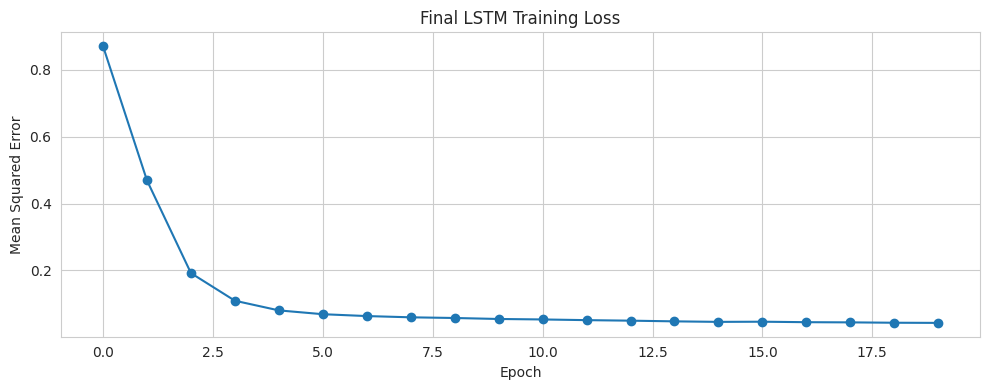

In [ ]:
#Plot the final training loss

plt.figure(figsize=(10, 4))

plt.plot(
    final_history.history["loss"],
    marker="o"
)

plt.title("Final LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.tight_layout()
plt.show()

Forecast the final two years

The model predicts 24 hours at a time. Its predictions are then added to the history before forecasting the following day.

This prevents the actual test-period electricity load from leaking into later forecasts.

In [ ]:
def recursive_lstm_forecast(
    model,
    training_series,
    forecast_index,
    scaler,
    lookback,
    output_horizon
):
    """
    Produce a recursive multi-step forecast.

    Actual values from the test period are not used.
    """

    initial_history = training_series.iloc[-lookback:]

    history_features, _ = make_feature_matrix(
        initial_history,
        scaler
    )

    scaled_predictions = []

    for start in range(
        0,
        len(forecast_index),
        output_horizon
    ):

        remaining = len(forecast_index) - start
        block_length = min(
            output_horizon,
            remaining
        )

        model_input = history_features[-lookback:]

        model_input = np.expand_dims(
            model_input,
            axis=0
        )

        # Faster than repeatedly calling model.predict()
        prediction_block = model(
            model_input,
            training=False
        ).numpy().ravel()

        prediction_block = prediction_block[
            :block_length
        ]

        scaled_predictions.extend(
            prediction_block.tolist()
        )

        block_index = forecast_index[
            start:start + block_length
        ]

        calendar = make_calendar_features(
            block_index
        )

        new_feature_rows = np.column_stack([
            prediction_block,
            calendar
        ]).astype(np.float32)

        history_features = np.vstack([
            history_features,
            new_feature_rows
        ])

        history_features = history_features[
            -lookback:
        ]

    scaled_predictions = np.asarray(
        scaled_predictions
    )

    predictions = scaler.inverse_transform(
        scaled_predictions.reshape(-1, 1)
    ).ravel()

    return pd.Series(
        predictions,
        index=forecast_index,
        name="LSTM_forecast"
    )

In [ ]:
lstm_forecast = recursive_lstm_forecast(
    model=final_model,
    training_series=train_full,
    forecast_index=test.index,
    scaler=final_scaler,
    lookback=LOOKBACK,
    output_horizon=OUTPUT_HORIZON
)

print(lstm_forecast.head())
print("Forecast observations:", len(lstm_forecast))

timestamp
2018-10-02 00:00:00+00:00    44833.489020
2018-10-02 01:00:00+00:00    44817.526163
2018-10-02 02:00:00+00:00    46081.425494
2018-10-02 03:00:00+00:00    49205.929333
2018-10-02 04:00:00+00:00    55812.994094
Freq: h, Name: LSTM_forecast, dtype: float64
Forecast observations: 17520


In [ ]:
#Calculate evaluation metrics

actual = test.to_numpy()
predicted = lstm_forecast.to_numpy()

In [ ]:
mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

mape = np.mean(
    np.abs(
        (actual - predicted) / actual
    )
) * 100

smape = np.mean(
    200
    * np.abs(actual - predicted)
    / (
        np.abs(actual)
        + np.abs(predicted)
        + 1e-8
    )
)

bias = np.mean(
    predicted - actual
)

r_squared = r2_score(
    actual,
    predicted
)

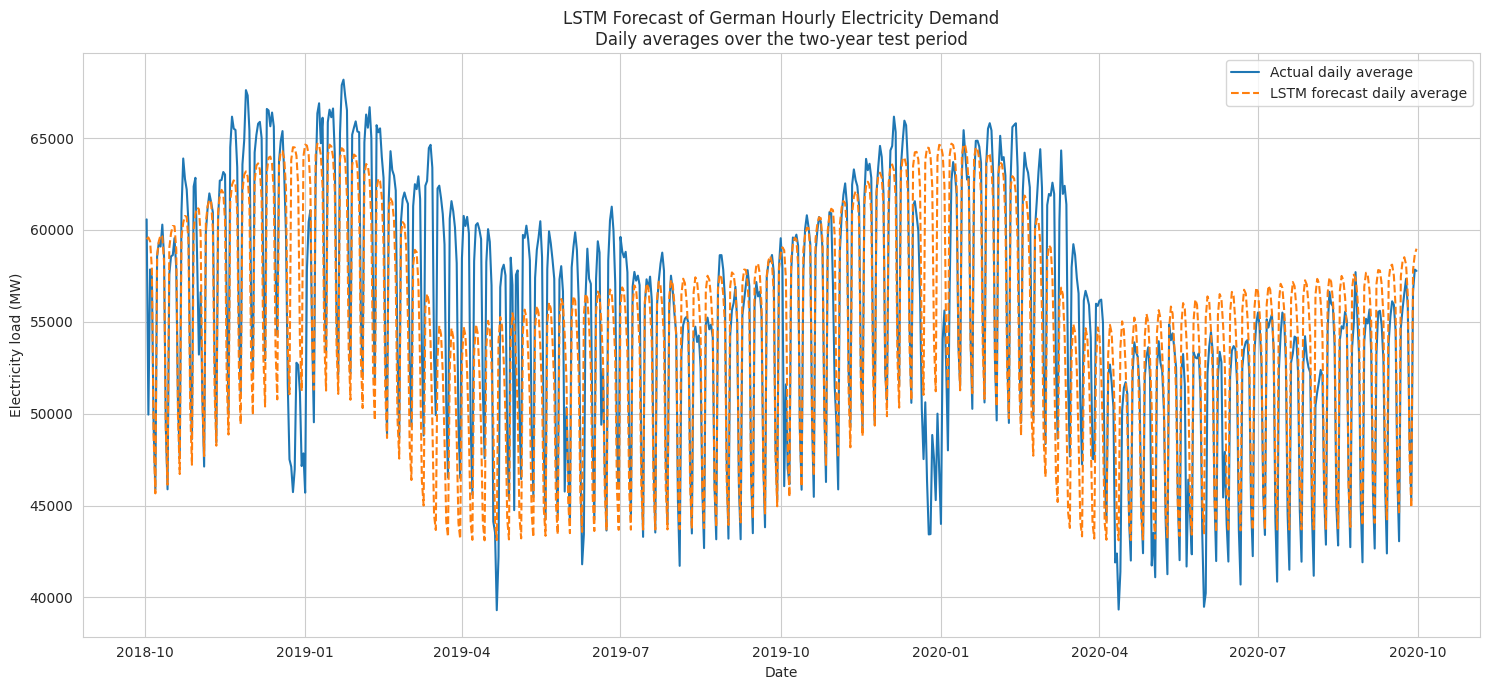

In [ ]:
plot_data = pd.DataFrame({
    "Actual": test,
    "LSTM Forecast": lstm_forecast
})

daily_plot_data = plot_data.resample("D").mean()

plt.figure(figsize=(15, 7))

plt.plot(
    daily_plot_data.index,
    daily_plot_data["Actual"],
    label="Actual daily average",
    linewidth=1.5
)

plt.plot(
    daily_plot_data.index,
    daily_plot_data["LSTM Forecast"],
    label="LSTM forecast daily average",
    linestyle="--"
)

plt.title(
    "LSTM Forecast of German Hourly Electricity Demand\n"
    "Daily averages over the two-year test period"
)

plt.xlabel("Date")
plt.ylabel("Electricity load (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

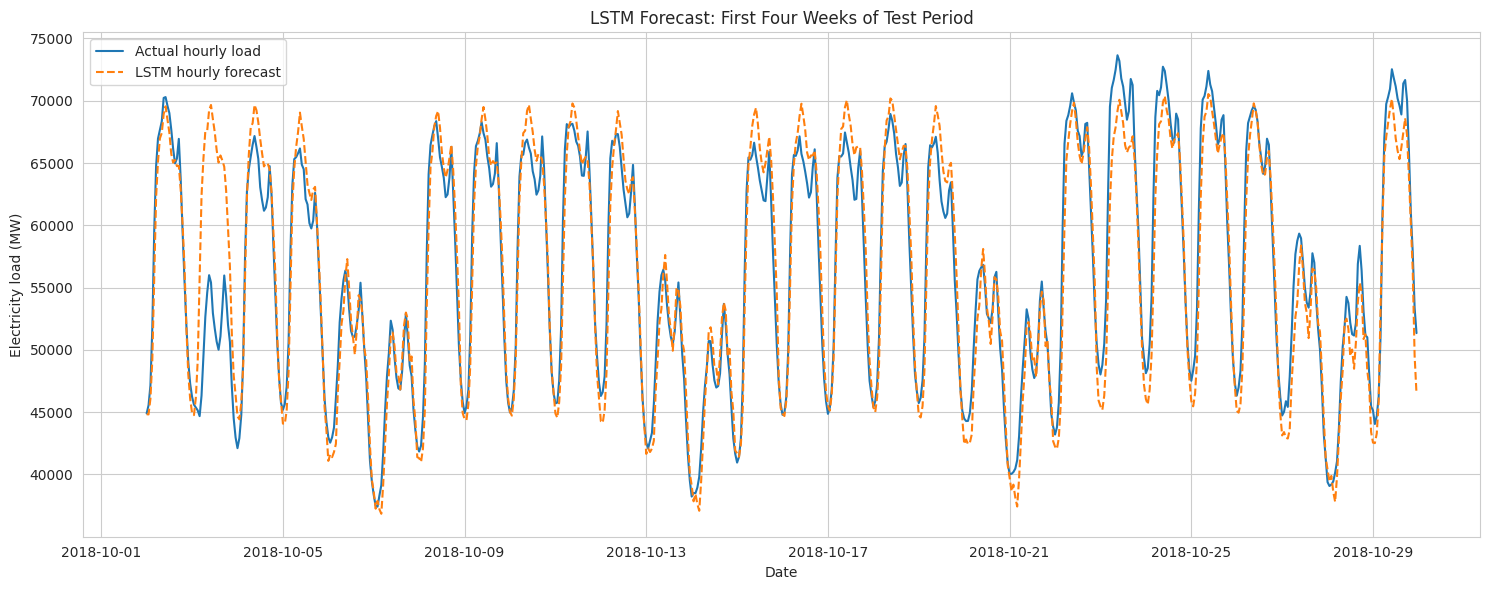

In [ ]:
#Plot the first four forecast weeks at hourly resolution:
FIRST_FOUR_WEEKS = 24 * 7 * 4

plt.figure(figsize=(15, 6))

plt.plot(
    test.index[:FIRST_FOUR_WEEKS],
    test.iloc[:FIRST_FOUR_WEEKS],
    label="Actual hourly load",
    linewidth=1.5
)

plt.plot(
    lstm_forecast.index[:FIRST_FOUR_WEEKS],
    lstm_forecast.iloc[:FIRST_FOUR_WEEKS],
    label="LSTM hourly forecast",
    linestyle="--"
)

plt.title("LSTM Forecast: First Four Weeks of Test Period")
plt.xlabel("Date")
plt.ylabel("Electricity load (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
forecast_results = pd.DataFrame({
    "Actual": test,
    "LSTM Forecast": lstm_forecast
})

forecast_results.to_csv(
    "lstm_hourly_two_year_forecast.csv"
)

lstm_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "SMAPE",
        "Bias",
        "R-squared"
    ],
    "Value": [
        mae,
        rmse,
        mape,
        smape,
        bias,
        r_squared
    ]
})

lstm_metrics.to_csv(
    "lstm_hourly_metrics.csv",
    index=False
)

tuning_results_df.to_csv(
    "lstm_hyperparameter_results.csv",
    index=False
)

final_model.save(
    "german_electricity_lstm.keras"
)
